# Install & Import Required Libraries

In [ ]:
!pip install nltk spacy gensim tensorflow scikit-learn beautifulsoup4 matplotlib seaborn pandas numpy
!python -m spacy download en_core_web_sm
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 121.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import string
import time

from bs4 import BeautifulSoup

import nltk
from nltk.tokenize import sent_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords as nltk_stopwords
nltk.download('punkt_tab')
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

import spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
nlp_parser = spacy.load('en_core_web_sm')

from gensim.models import Word2Vec

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, classification_report)

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM,
                                     Bidirectional, GlobalAveragePooling1D, Input, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# Dataset

In [ ]:
train_df = pd.read_csv('/content/Training_data_8.csv')
test_df  = pd.read_csv('/content/Test_data.csv')

In [ ]:
train_df.columns = ['text', 'label']
test_df.columns  = ['text', 'label']

# EDA

In [ ]:
print("TRAINING DATA SUMMARY")
total_train_rows = len(train_df)
missing_train_text = train_df["text"].isnull().sum()
missing_train_label = train_df["label"].isnull().sum()

print(f"Total Rows: {total_train_rows:,}")
print(f"Missing Text: {missing_train_text}")
print(f"Missing Labels: {missing_train_label}")

TRAINING DATA SUMMARY
Total Rows: 93,151
Missing Text: 0
Missing Labels: 0


In [ ]:
print("CLASS DISTRIBUTION (TRAINING)")
train_class_counts = train_df['label'].value_counts()
train_class_percent = (train_class_counts / total_train_rows * 100).round(2)
print("Counts:\n", train_class_counts)

CLASS DISTRIBUTION (TRAINING)
Counts:
 label
Business                  36316
Science and Technology    22422
World News                19118
Sports                    15295
Name: count, dtype: int64


In [ ]:
print("\nPercentages (%):\n", train_class_percent)


Percentages (%):
 label
Business                  38.99
Science and Technology    24.07
World News                20.52
Sports                    16.42
Name: count, dtype: float64


In [ ]:
print("TESTING DATA SUMMARY")

total_test_rows = len(test_df)
missing_test_text = test_df["text"].isnull().sum()
missing_test_label = test_df["label"].isnull().sum()

print(f"Total Rows: {total_test_rows:,}")
print(f"Missing Text: {missing_test_text}")
print(f"Missing Labels: {missing_test_label}")

TESTING DATA SUMMARY
Total Rows: 12,000
Missing Text: 0
Missing Labels: 0


In [ ]:
print("CLASS DISTRIBUTION (TESTING)")

test_class_counts = test_df['label'].value_counts()
test_class_percent = (test_class_counts / total_test_rows * 100).round(2)

print("Counts:\n", test_class_counts)

CLASS DISTRIBUTION (TESTING)
Counts:
 label
Science and Technology    3000
World News                3000
Business                  3000
Sports                    3000
Name: count, dtype: int64


In [ ]:
print("\nPercentages (%):\n", test_class_percent)


Percentages (%):
 label
Science and Technology    25.0
World News                25.0
Business                  25.0
Sports                    25.0
Name: count, dtype: float64


In [ ]:
print("SAMPLE TRAINING DATA")
train_df.sample(5)

SAMPLE TRAINING DATA


,text,label
50122,<html> <body> News Headlines:\n <br> <b> Lloyd...,Business
47273,<html> <body> News Headlines:\n <br> <b> New F...,World News
65817,<html> <body> News Headlines:\n <br> <b> Rain ...,Sports
62468,<html> <body> News Headlines:\n <br> <b> CCIA ...,Business
20692,<html> <body> News Headlines:\n <br> <b> UK PM...,World News


In [ ]:
print("SAMPLE TESTING DATA")
test_df.sample(5)

SAMPLE TESTING DATA


,text,label
1748,<html> <body> <br> <br> News Headlines:\n <b>...,Sports
10859,<html> <body> <br> <br> News Headlines:\n <b>...,Science and Technology
7917,<html> <body> <br> <br> News Headlines:\n <b>...,World News
2963,<html> <body> <br> <br> News Headlines:\n <b>...,World News
1757,<html> <body> <br> <br> News Headlines:\n <b>...,Business


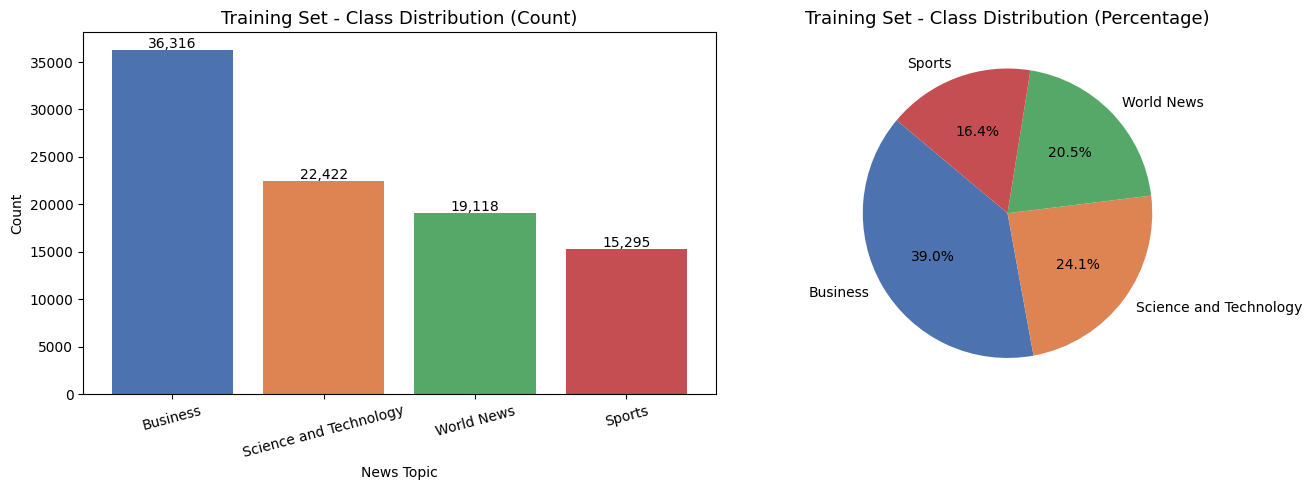

Observation: Training set is imbalanced. Business has the highest share (~39%),
while Sports has the lowest (~16%). Macro F1 score will be used for evaluation.


In [ ]:
label_counts_train = train_df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(label_counts_train.index, label_counts_train.values,
            color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[0].set_title('Training Set - Class Distribution (Count)', fontsize=13)
axes[0].set_xlabel('News Topic')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

for idx, val in enumerate(label_counts_train.values):
    axes[0].text(idx, val + 200, f'{val:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(label_counts_train.values,
            labels=label_counts_train.index,
            autopct='%1.1f%%',
            startangle=140,
            colors=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1].set_title('Training Set - Class Distribution (Percentage)', fontsize=13)

plt.tight_layout()
plt.show()

print('Observation: Training set is imbalanced. Business has the highest share (~39%),')
print('while Sports has the lowest (~16%). Macro F1 score will be used for evaluation.')

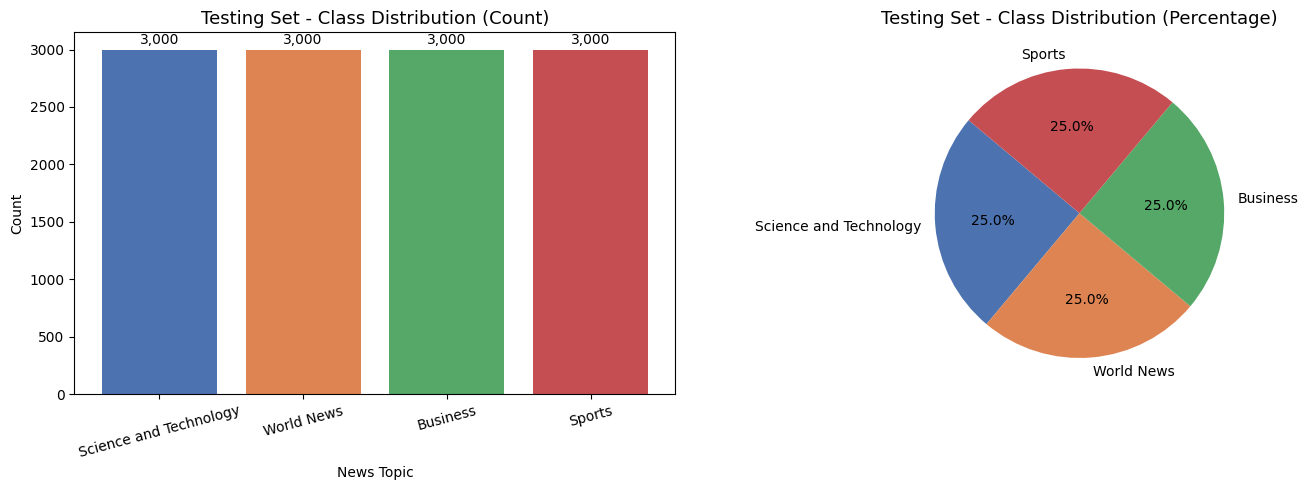

Observation: Testing set is balanced with equal samples per class (25% each).


In [ ]:
label_counts_test = test_df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(label_counts_test.index, label_counts_test.values,
            color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[0].set_title('Testing Set - Class Distribution (Count)', fontsize=13)
axes[0].set_xlabel('News Topic')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

for idx, val in enumerate(label_counts_test.values):
    axes[0].text(idx, val + 50, f'{val:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(label_counts_test.values,
            labels=label_counts_test.index,
            autopct='%1.1f%%',
            startangle=140,
            colors=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1].set_title('Testing Set - Class Distribution (Percentage)', fontsize=13)

plt.tight_layout()
plt.show()

print('Observation: Testing set is balanced with equal samples per class (25% each).')

In [ ]:
def remove_html_tags(text_value):
    """Remove HTML tags and decode HTML entities using BeautifulSoup."""
    parsed_content = BeautifulSoup(str(text_value), 'html.parser')
    return parsed_content.get_text(separator=' ').strip()

In [ ]:
for idx in range(3):
    current_label = train_df["label"].iloc[idx]
    raw_text_sample = train_df['text'].iloc[idx][:200]
    cleaned_text_sample = remove_html_tags(train_df['text'].iloc[idx])[:200]

    print(f'Sample {idx + 1} (Label: {current_label})')
    print('RAW:', raw_text_sample)
    print('CLEANED:', cleaned_text_sample)
    print("\n\n")

Sample 1 (Label: Business)
RAW: <html> <body> News Headlines:
 <br> <b> Nortel Networks Names Clent Richardson Chief Marketing Officer Nortel Networks Corp., North America #39;s bigger maker of phone equipment, named Clent Richardso
CLEANED: News Headlines:
     Nortel Networks Names Clent Richardson Chief Marketing Officer Nortel Networks Corp., North America #39;s bigger maker of phone equipment, named Clent Richardson as its chief mark



Sample 2 (Label: Business)
RAW: <html> <body> News Headlines:
 <br> <b> APEC Countries to Standardize Trade Pacts  SANTIAGO, Chile (Reuters) - Pacific Rim nations have agreed  to set minimum standards for two-country free trade pact
CLEANED: News Headlines:
     APEC Countries to Standardize Trade Pacts  SANTIAGO, Chile (Reuters) - Pacific Rim nations have agreed  to set minimum standards for two-country free trade pacts  proliferating ac



Sample 3 (Label: Business)
RAW: <html> <body> News Headlines:
 <br> <b> Record Deficit for a Crucial Trade F

In [ ]:
sampled_train_df = train_df.sample(5000, random_state=42).copy()

sampled_train_df['clean_text'] = sampled_train_df['text'].apply(remove_html_tags)
sampled_train_df['char_length'] = sampled_train_df['clean_text'].str.len()
sampled_train_df['word_count'] = sampled_train_df['clean_text'].apply(lambda txt: len(txt.split()))

print('Character Length Statistics (Sample of 5000 from Training Data):')
print(sampled_train_df.groupby('label')['char_length'].describe().round(1))

print()
print('Word Count Statistics (Sample of 5000 from Training Data):')
print(sampled_train_df.groupby('label')['word_count'].describe().round(1))

Character Length Statistics (Sample of 5000 from Training Data):
                         count   mean   std    min    25%    50%    75%    max
label                                                                         
Business                1925.0  260.8  61.2  121.0  224.0  256.0  287.0  781.0
Science and Technology  1177.0  259.2  79.7  109.0  210.0  254.0  294.0  898.0
Sports                   852.0  247.0  50.1  128.0  212.0  241.0  275.0  675.0
World News              1046.0  263.8  63.4  128.0  227.0  264.0  295.0  718.0

Word Count Statistics (Sample of 5000 from Training Data):
                         count  mean   std   min   25%   50%   75%    max
label                                                                    
Business                1925.0  39.6   8.0  13.0  35.0  39.0  44.0  107.0
Science and Technology  1177.0  39.6  12.6  12.0  32.0  39.0  45.0  147.0
Sports                   852.0  40.1   8.9  15.0  34.0  39.0  45.0  115.0
World News              1046.0 

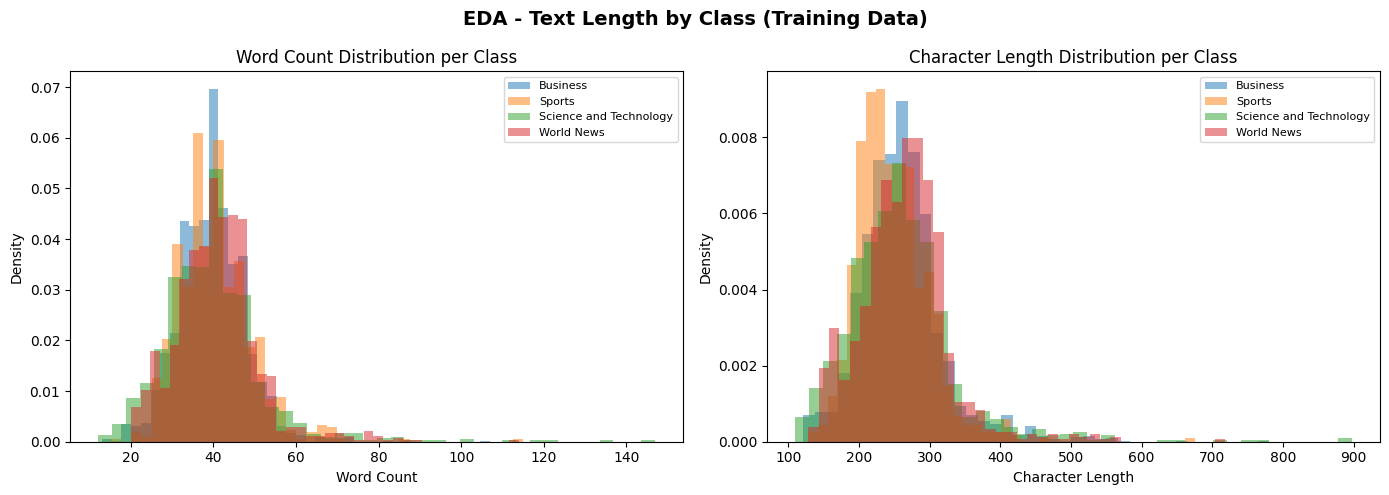

In [ ]:
fig, plot_axes = plt.subplots(1, 2, figsize=(14, 5))

for class_label in sampled_train_df['label'].unique():
    class_subset = sampled_train_df[sampled_train_df['label'] == class_label]

    plot_axes[0].hist(class_subset['word_count'],
                      bins=40,
                      alpha=0.5,
                      label=class_label,
                      density=True)

    plot_axes[1].hist(class_subset['char_length'],
                      bins=40,
                      alpha=0.5,
                      label=class_label,
                      density=True)

plot_axes[0].set_title('Word Count Distribution per Class')
plot_axes[0].set_xlabel('Word Count')
plot_axes[0].set_ylabel('Density')
plot_axes[0].legend(fontsize=8)

plot_axes[1].set_title('Character Length Distribution per Class')
plot_axes[1].set_xlabel('Character Length')
plot_axes[1].set_ylabel('Density')
plot_axes[1].legend(fontsize=8)

plt.suptitle('EDA - Text Length by Class (Training Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

--- Sample 1 (Label: Business) ---
RAW     : <html> <body> News Headlines:
 <br> <b> Nortel Networks Names Clent Richardson Chief Marketing Officer Nortel Networks Corp., North America #39;s bigger maker of phone equipment, named Clent Richardso
STRIPPED: News Headlines:
     Nortel Networks Names Clent Richardson Chief Marketing Officer Nortel Networks Corp., North America #39;s bigger maker of phone equipment, named Clent Richardson as its chief mark

--- Sample 2 (Label: Business) ---
RAW     : <html> <body> News Headlines:
 <br> <b> APEC Countries to Standardize Trade Pacts  SANTIAGO, Chile (Reuters) - Pacific Rim nations have agreed  to set minimum standards for two-country free trade pact
STRIPPED: News Headlines:
     APEC Countries to Standardize Trade Pacts  SANTIAGO, Chile (Reuters) - Pacific Rim nations have agreed  to set minimum standards for two-country free trade pacts  proliferating ac

--- Sample 3 (Label: Business) ---
RAW     : <html> <body> News Headlines:
 <br> <b>

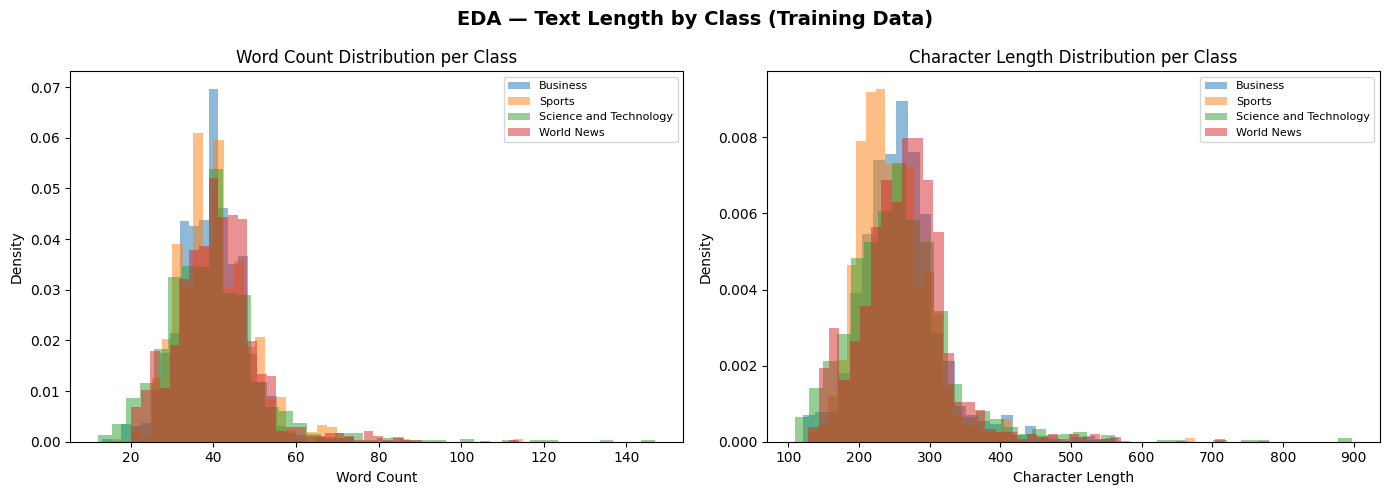

Observation: All classes have very similar text-length distributions,
meaning length alone is not a discriminating feature.


In [ ]:
def strip_html(text):
    soup = BeautifulSoup(str(text), 'html.parser')
    return soup.get_text(separator=' ').strip()

# Preview stripped text for first 3 rows
for i in range(3):
    print(f'--- Sample {i+1} (Label: {train_df["label"].iloc[i]}) ---')
    print('RAW     :', train_df['text'].iloc[i][:200])
    print('STRIPPED:', strip_html(train_df['text'].iloc[i])[:200])
    print()

# Text Length Analysis (sample for speed)
sample_df = train_df.sample(5000, random_state=42).copy()
sample_df['clean_text'] = sample_df['text'].apply(strip_html)
sample_df['char_len']   = sample_df['clean_text'].str.len()
sample_df['word_count'] = sample_df['clean_text'].apply(lambda x: len(x.split()))

print('Character Length Stats (sampled 5000 from train):')
print(sample_df.groupby('label')['char_len'].describe().round(1))
print()
print('Word Count Stats (sampled 5000 from train):')
print(sample_df.groupby('label')['word_count'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label in sample_df['label'].unique():
    subset = sample_df[sample_df['label'] == label]
    axes[0].hist(subset['word_count'], bins=40, alpha=0.5, label=label, density=True)
    axes[1].hist(subset['char_len'],   bins=40, alpha=0.5, label=label, density=True)

axes[0].set_title('Word Count Distribution per Class')
axes[0].set_xlabel('Word Count'); axes[0].set_ylabel('Density'); axes[0].legend(fontsize=8)
axes[1].set_title('Character Length Distribution per Class')
axes[1].set_xlabel('Character Length'); axes[1].set_ylabel('Density'); axes[1].legend(fontsize=8)

plt.suptitle('EDA — Text Length by Class (Training Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observation: All classes have very similar text-length distributions,')
print('meaning length alone is not a discriminating feature.')

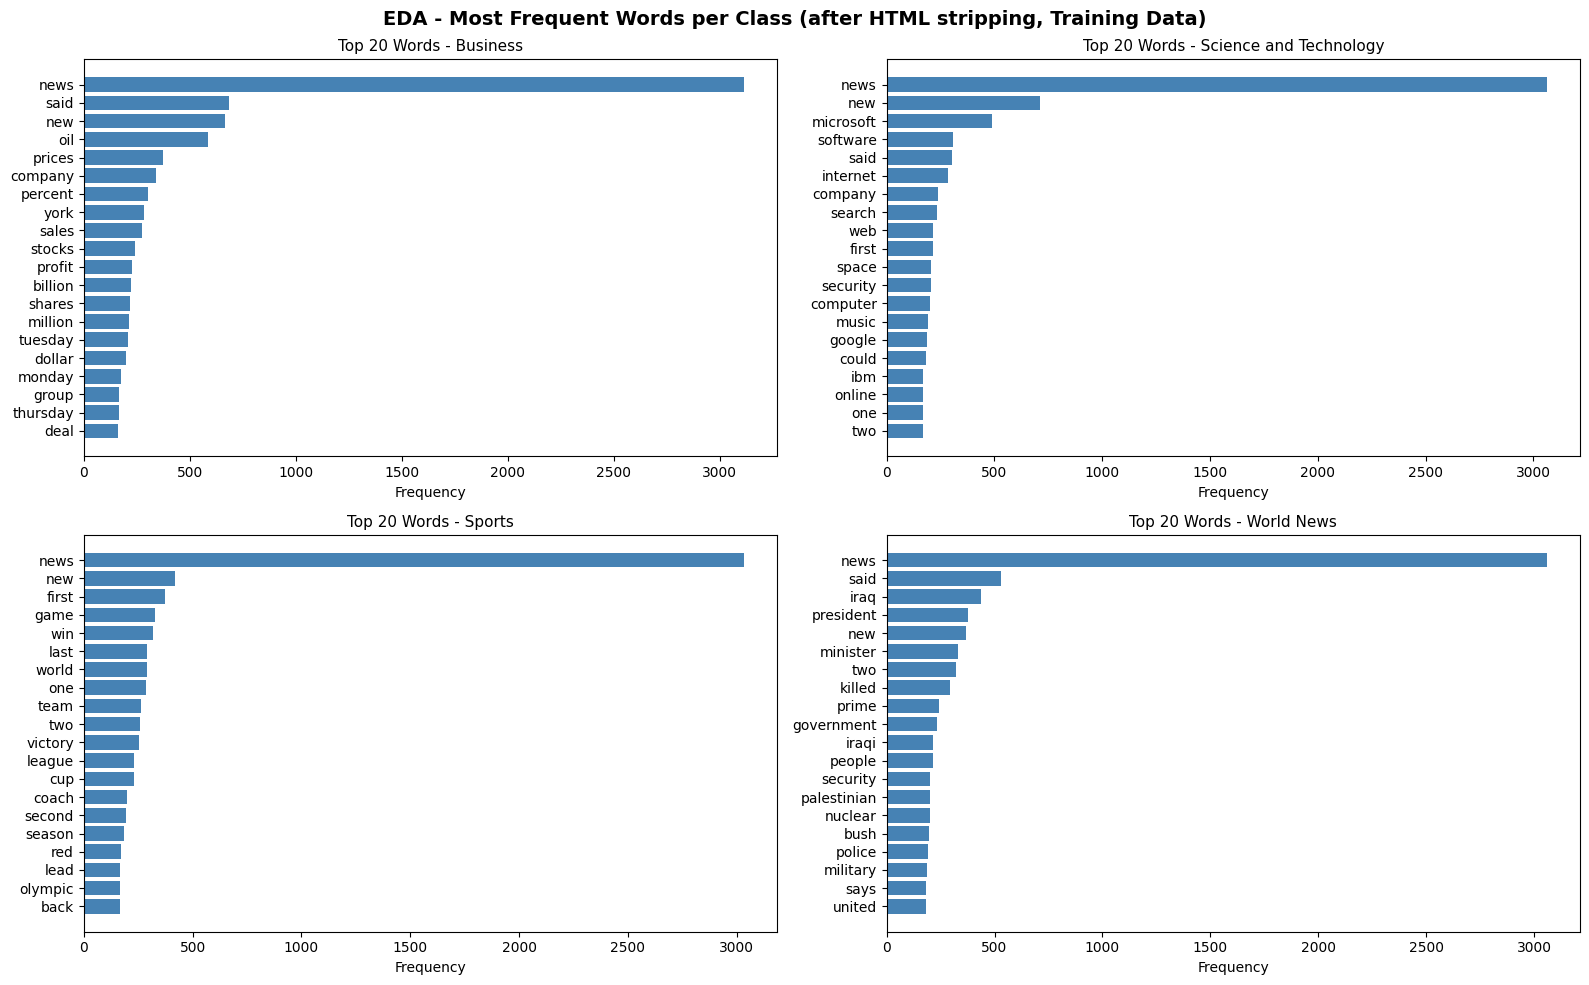


Unique tokens (raw, sampled 5k from training data): 26,822
Total tokens  (raw, sampled 5k from training data): 199,772


In [ ]:
# Cell 5: EDA — Most Frequent Words per Class & Vocabulary Size

stopword_set = set(nltk_stopwords.words('english'))

fig, axis_array = plt.subplots(2, 2, figsize=(16, 10))
axis_array = axis_array.flatten()

for plot_index, class_label in enumerate(sorted(train_df['label'].unique())):
    class_text_samples = train_df[train_df['label'] == class_label]['text'] \
        .sample(3000, random_state=42) \
        .apply(remove_html_tags)

    token_list = []
    for text_entry in class_text_samples:
        token_list.extend([
            token.lower() for token in text_entry.split()
            if token.lower() not in stopword_set and token.isalpha() and len(token) > 2
        ])

    top_tokens = Counter(token_list).most_common(20)
    tokens_plot, frequencies_plot = zip(*top_tokens)

    axis_array[plot_index].barh(tokens_plot[::-1], frequencies_plot[::-1], color='steelblue')
    axis_array[plot_index].set_title(f'Top 20 Words - {class_label}', fontsize=11)
    axis_array[plot_index].set_xlabel('Frequency')

plt.suptitle('EDA - Most Frequent Words per Class (after HTML stripping, Training Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Vocabulary size analysis
aggregate_tokens = []
for text_entry in sampled_train_df['clean_text']:
    aggregate_tokens.extend(text_entry.lower().split())

print(f'\nUnique tokens (raw, sampled 5k from training data): {len(set(aggregate_tokens)):,}')
print(f'Total tokens  (raw, sampled 5k from training data): {len(aggregate_tokens):,}')

<pre>
Observation: Class-specific vocabulary is clearly visible. For example, sports-related terms
(game, season, player) differ from business-related terms (company, market, billion).

EDA Summary:
  • 93,151 training samples | 12,000 test samples | 4 classes
  • Training data is imbalanced (Business ~39%, Sports ~16%)
  • Testing data is balanced (3,000 samples per class)
  • Text contains HTML formatting; actual content length is relatively short
  • Distinct vocabulary exists across different classes
  • Stopwords are frequent across all classes and should be removed
  • HTML entities (e.g., &amp;, &quot;) require proper decoding
</pre>

# Label Encoding

In [ ]:
label_encoder = LabelEncoder()

train_df['encoded_label'] = label_encoder.fit_transform(train_df['label'])
test_df['encoded_label']  = label_encoder.transform(test_df['label'])

In [ ]:
num_classes = len(label_encoder.classes_)

print('Classes:', label_encoder.classes_)
print('Encoded:', list(range(num_classes)))

Classes: ['Business' 'Science and Technology' 'Sports' 'World News']
Encoded: [0, 1, 2, 3]


In [ ]:
train_size = len(train_df)
test_size  = len(test_df)

print(f'Train size: {train_size:,}')
print(f'Test size : {test_size:,}')

Train size: 93,151
Test size : 12,000


In [ ]:
print('Train class distribution (encoded):')
print(train_df['encoded_label'].value_counts().sort_index())

print('\nTest class distribution (encoded):')
print(test_df['encoded_label'].value_counts().sort_index())

Train class distribution (encoded):
encoded_label
0    36316
1    22422
2    15295
3    19118
Name: count, dtype: int64

Test class distribution (encoded):
encoded_label
0    3000
1    3000
2    3000
3    3000
Name: count, dtype: int64


In [ ]:
y_train = train_df['encoded_label'].values
y_test  = test_df['encoded_label'].values

print('y_train shape:', y_train.shape, '| unique:', np.unique(y_train))
print('y_test  shape:', y_test.shape,  '| unique:', np.unique(y_test))

y_train shape: (93151,) | unique: [0 1 2 3]
y_test  shape: (12000,) | unique: [0 1 2 3]


# Preprocessing
### No Preprocessing
### Optimum Preprocessing
### Extreme Preprocessing

## No Preprocessing


In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")
print("Active pipes:", nlp.pipe_names)

train_raw = train_df['text'].tolist()
test_raw  = test_df['text'].tolist()

print(f'\nNo-preprocessing sample (train):\n{train_raw[0][:300]}')
print(f'\nNo-preprocessing sample (test):\n{test_raw[0][:300]}')
print(f'\nTrain raw count: {len(train_raw):,}')
print(f'Test raw count: {len(test_raw):,}')

Active pipes: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

No-preprocessing sample (train):
<html> <body> News Headlines:
 <br> <b> Nortel Networks Names Clent Richardson Chief Marketing Officer Nortel Networks Corp., North America #39;s bigger maker of phone equipment, named Clent Richardson as its chief marketing officer, filling a position that was vacant for almost two years. </b> 
 <b

No-preprocessing sample (test):
<html> <body> <br> <br> News Headlines:
  <b> Orange Unveils 3G Phones in Long-Delayed Launch  LONDON/PARIS (Reuters) - Orange unveiled its  third-generation (3G) mobile phones in a long-delayed  commercial launch, with seven new handset models aimed at its  key French market and at least four at Br

Train raw count: 93,151
Test raw count: 12,000


## Extreme Preprocessing - Approach
###### Steps: HTML strip → lowercase → SpaCy tokenize → POS filter (NOUN/VERB/ADJ/ADV) → stopword removal → stemming (PorterStemmer)


In [ ]:
text_stemmer = PorterStemmer()
allowed_pos_tags = {'NOUN', 'VERB', 'ADJ', 'ADV'}

def preprocess_text_extreme(text_series, batch_size=256, n_process=1):
    cleaned_texts = [remove_html_tags(text).lower() for text in text_series]
    processed_results = []

    for parsed_doc in nlp.pipe(cleaned_texts, batch_size=batch_size, n_process=n_process):
        final_tokens = []
        for token in parsed_doc:
            if token.pos_ not in allowed_pos_tags:
                continue
            if token.is_stop:
                continue
            if not token.is_alpha or len(token.text) < 2:
                continue
            final_tokens.append(text_stemmer.stem(token.text))
        processed_results.append(' '.join(final_tokens))

    return processed_results


print('Running extreme preprocessing on training data...')
start_time = time.time()
train_processed_extreme = preprocess_text_extreme(train_df['text'])
print(f'Training completed in {time.time() - start_time:.1f}s')

print('Running extreme preprocessing on testing data...')
start_time = time.time()
test_processed_extreme = preprocess_text_extreme(test_df['text'])
print(f'Testing completed in {time.time() - start_time:.1f}s')

print('\nSample (training):')
print(train_processed_extreme[0][:200])

print('\nSample (testing):')
print(test_processed_extreme[0][:200])

Running extreme preprocessing on training data...
Training completed in 667.6s
Running extreme preprocessing on testing data...
Testing completed in 77.9s

Sample (training):
news headlin nortel network name clent chief market offic bigger maker phone equip name clent chief market offic fill posit vacant year

Sample (testing):
news headlin orang unveil phone long delay launch unveil gener mobil phone long delay commerci launch new handset model aim key french market time


## Extreme Preprocessing
###### POS Tagging & Dependency Parse Demonstration

In [ ]:
demo_clean_text = remove_html_tags(train_df['text'].iloc[0])
demo_doc = nlp(demo_clean_text[:300])

In [ ]:
print('POS Tags (first 20 tokens)')
for token in demo_doc[:20]:
    print(f'{token.text:<20} POS: {token.pos_:<8} TAG: {token.tag_:<8}')

POS Tags (first 20 tokens)
News                 POS: NOUN     TAG: NN      
Headlines            POS: PROPN    TAG: NNPS    
:                    POS: PUNCT    TAG: :       

                    POS: SPACE    TAG: _SP     
Nortel               POS: PROPN    TAG: NNP     
Networks             POS: PROPN    TAG: NNPS    
Names                POS: PROPN    TAG: NNPS    
Clent                POS: PROPN    TAG: NNP     
Richardson           POS: PROPN    TAG: NNP     
Chief                POS: PROPN    TAG: NNP     
Marketing            POS: PROPN    TAG: NNP     
Officer              POS: PROPN    TAG: NNP     
Nortel               POS: PROPN    TAG: NNP     
Networks             POS: PROPN    TAG: NNP     
Corp.                POS: PROPN    TAG: NNP     
,                    POS: PUNCT    TAG: ,       
North                POS: PROPN    TAG: NNP     
America              POS: PROPN    TAG: NNP     
#                    POS: SYM      TAG: $       
39;s                 POS: NUM      TAG: CD

In [ ]:
print('Dependency Parse (first sentence)')
for token in list(demo_doc.sents)[0]:
    print(f'{token.text:<15} HEAD: {token.head.text:<15} DEP: {token.dep_}')

Dependency Parse (first sentence)
News            HEAD: Headlines       DEP: compound
Headlines       HEAD: filling         DEP: nsubj
:               HEAD: Headlines       DEP: punct

               HEAD: :               DEP: dep
Nortel          HEAD: Networks        DEP: compound
Networks        HEAD: Names           DEP: compound
Names           HEAD: Officer         DEP: compound
Clent           HEAD: Officer         DEP: compound
Richardson      HEAD: Officer         DEP: compound
Chief           HEAD: Officer         DEP: compound
Marketing       HEAD: Officer         DEP: compound
Officer         HEAD: Corp.           DEP: compound
Nortel          HEAD: Corp.           DEP: compound
Networks        HEAD: Corp.           DEP: compound
Corp.           HEAD: Headlines       DEP: appos
,               HEAD: Corp.           DEP: punct
North           HEAD: America         DEP: compound
America         HEAD: Corp.           DEP: npadvmod
#               HEAD: 39;s            DEP: nmod

## Optimum Preprocessing

<pre>
Decision rationale (from EDA):
  HTML stripping — raw text contains HTML tags/entities
  Lowercasing — reduces vocabulary size without losing meaning
  SpaCy tokenization + lemmatization — normalizes inflected forms (running→run)
      without over-reducing like stemming ('technology'→'technolog')
  Stopword removal — high-frequency words add no discriminative value
  Stemming EXCLUDED — domain-specific terms ('earnings','league') are
      important discriminators; stemming corrupts them
  POS filter EXCLUDED — in short headlines, all word types carry meaning
</pre>

In [ ]:
nlp.select_pipes(enable=["tok2vec", "tagger", "morphologizer", "lemmatizer"])

['parser', 'attribute_ruler', 'ner']

In [ ]:
def preprocess_text_optimum(parsed_doc):
    return ' '.join(
        token.lemma_
        for token in parsed_doc
        if not token.is_stop
        and token.is_alpha
        and len(token.lemma_) > 1
    )

In [ ]:
def batch_preprocess_optimum(text_series, batch_size=256):
    cleaned_texts = [
        re.sub(r'\s+', ' ',
               re.sub(r'[^a-z\s]', ' ',
                      remove_html_tags(text).lower())).strip()
        for text in text_series
    ]

    return [
        preprocess_text_optimum(doc)
        for doc in nlp.pipe(cleaned_texts, batch_size=batch_size)
    ]

In [ ]:
print('Running optimum preprocessing on training data...')
start_time = time.time()

train_processed_optimum = batch_preprocess_optimum(train_df['text'])

print(f'Training completed in {time.time() - start_time:.1f}s')

Running optimum preprocessing on training data...
Training completed in 214.5s


In [ ]:
print('Running optimum preprocessing on testing data...')
start_time = time.time()

test_processed_optimum = batch_preprocess_optimum(test_df['text'])

print(f'Testing completed in {time.time() - start_time:.1f}s')

Running optimum preprocessing on testing data...
Testing completed in 27.1s


In [ ]:
print('Sample (training):')
print(train_processed_optimum[0][:200])

print('\nSample (testing):')
print(test_processed_optimum[0][:200])

Sample (training):
news headlines nortel networks names clent richardson chief marketing officer nortel networks corp north america bigger maker phone equipment named clent richardson chief marketing officer filling pos

Sample (testing):
news headlines orange unveils phones long delayed launch london paris reuters orange unveiled generation mobile phones long delayed commercial launch seven new handset models aimed key french market b


In [ ]:
sample_index = 5

print('Original (HTML):')
print(train_df['text'].iloc[sample_index][:300])
print()

print('No Preprocessing (same as original):')
print(train_df['text'].iloc[sample_index][:300])
print()

print('Extreme Preprocessing:')
print(train_processed_extreme[sample_index])
print()

print('Optimum Preprocessing:')
print(train_processed_optimum[sample_index])

Original (HTML):
<html> <body> News Headlines:
 <br> <b> Delta to cut up to 6,900 jobs CHICAGO - Delta Air Lines (DAL) said Wednesday it plans to eliminate between 6,000 and 6,900 jobs during the next 18 months, implement a 10 across-the-board pay reduction and reduce employee benefits. </b> 
 <br> <br> 

No Preprocessing (same as original):
<html> <body> News Headlines:
 <br> <b> Delta to cut up to 6,900 jobs CHICAGO - Delta Air Lines (DAL) said Wednesday it plans to eliminate between 6,000 and 6,900 jobs during the next 18 months, implement a 10 across-the-board pay reduction and reduce employee benefits. </b> 
 <br> <br> 

Extreme Preprocessing:
news headlin delta cut job air line said plan elimin job month implement board pay reduct reduc employe benefit

Optimum Preprocessing:
news headlines delta cut jobs chicago delta air lines dal said wednesday plans eliminate jobs months implement board pay reduction reduce employee benefits


# TF-IDF Vectorization (for all 3 preprocessing variants)

##### Hyperparameter choices:
##### max_features=50000 — large vocab to capture domain terms
##### ngram_range=(1,2)  — unigrams + bigrams improve classification
##### sublinear_tf=True  — log(1+tf) dampens effect of very frequent terms
##### min_df=2           — ignore terms appearing in < 2 docs (noise)

#### IMPORTANT: TfidfVectorizer is fit ONLY on training data, transform on both.

In [ ]:
tfidf_config = dict(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

# No Preprocessing (Raw Text)
tfidf_vectorizer_raw = TfidfVectorizer(**tfidf_config)
X_train_tfidf_raw = tfidf_vectorizer_raw.fit_transform(train_df['text'])
X_test_tfidf_raw  = tfidf_vectorizer_raw.transform(test_df['text'])
print(f'TF-IDF Raw: train={X_train_tfidf_raw.shape}, test={X_test_tfidf_raw.shape}\n\n')

# Extreme Preprocessing
tfidf_vectorizer_extreme = TfidfVectorizer(**tfidf_config)
X_train_tfidf_extreme = tfidf_vectorizer_extreme.fit_transform(train_processed_extreme)
X_test_tfidf_extreme  = tfidf_vectorizer_extreme.transform(test_processed_extreme)
print(f'TF-IDF Extreme: train={X_train_tfidf_extreme.shape}, test={X_test_tfidf_extreme.shape}\n\n')


# Optimum Preprocessing
tfidf_vectorizer_optimum = TfidfVectorizer(**tfidf_config)
X_train_tfidf_optimum = tfidf_vectorizer_optimum.fit_transform(train_processed_optimum)
X_test_tfidf_optimum  = tfidf_vectorizer_optimum.transform(test_processed_optimum)
print(f'TF-IDF Optimum: train={X_train_tfidf_optimum.shape}, test={X_test_tfidf_optimum.shape}')

TF-IDF Raw: train=(93151, 50000), test=(12000, 50000)


TF-IDF Extreme: train=(93151, 50000), test=(12000, 50000)


TF-IDF Optimum: train=(93151, 50000), test=(12000, 50000)


# Skip-gram Word2Vec
#### Trained on training data only

##### Hyperparameter choices:
##### vector_size=128  — compact but expressive for short headlines
##### window=5         — context window of 5 words (standard for headlines)
##### sg=1             — Skip-gram (sg=0 would be CBOW)
##### min_count=2      — discard tokens with < 2 occurrences
##### workers=4        — parallel training
##### epochs=10        — sufficient convergence for this corpus size

In [ ]:
embedding_dim = 128
max_sequence_length = 60  # covers ~95th percentile of headline lengths

def train_skipgram_model(tokenized_corpus, model_name=''):
    print(f'Training Skip-gram [{model_name}]...')
    start_time = time.time()

    word2vec_model = Word2Vec(
        sentences=tokenized_corpus,
        vector_size=embedding_dim,
        window=5,
        sg=1,
        min_count=2,
        workers=4,
        epochs=10,
        seed=42
    )

    print(f'Completed in {time.time() - start_time:.1f}s | Vocabulary size: {len(word2vec_model.wv):,}')
    return word2vec_model


def tokenize_text_corpus(text_series):
    return [text.split() for text in text_series]


# Train Skip-gram ONLY on training data
skipgram_model_raw = train_skipgram_model(
    tokenize_text_corpus(train_df['text']),
    model_name='Raw'
)

skipgram_model_extreme = train_skipgram_model(
    tokenize_text_corpus(train_processed_extreme),
    model_name='Extreme'
)

skipgram_model_optimum = train_skipgram_model(
    tokenize_text_corpus(train_processed_optimum),
    model_name='Optimum'
)

Training Skip-gram [Raw]...
Completed in 292.9s | Vocabulary size: 81,320
Training Skip-gram [Extreme]...
Completed in 97.7s | Vocabulary size: 19,321
Training Skip-gram [Optimum]...
Completed in 170.1s | Vocabulary size: 37,047


# Configuring Padded Sequences & Embedding Matrices

In [ ]:
# Keras Tokenizer is fit ONLY on training data.
# Both train and test sequences are built from that same vocabulary.

def build_embedding_inputs(train_texts, test_texts, w2v_model, max_len=max_sequence_length):
    tokenizer = KerasTokenizer()
    tokenizer.fit_on_texts(train_texts)   # fit on train only
    vocab_size = len(tokenizer.word_index) + 1

    X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_texts),
                                maxlen=max_len, padding='post')
    X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(test_texts),
                                maxlen=max_len, padding='post')

    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    hits, misses = 0, 0

    for word, idx in tokenizer.word_index.items():
        if word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]
            hits += 1
        else:
            misses += 1

    print(f'  Vocab size: {vocab_size:,} | Hits: {hits:,} | OOV: {misses:,}')
    return X_train_seq, X_test_seq, embedding_matrix, vocab_size


print('Building embedding inputs for Raw...')
X_train_seq_raw, X_test_seq_raw, emb_matrix_raw, vocab_size_raw = \
    build_embedding_inputs(train_df['text'], test_df['text'], skipgram_model_raw)

print('Building embedding inputs for Extreme...')
X_train_seq_extreme, X_test_seq_extreme, emb_matrix_extreme, vocab_size_extreme = \
    build_embedding_inputs(train_processed_extreme, test_processed_extreme, skipgram_model_extreme)

print('Building embedding inputs for Optimum...')
X_train_seq_optimum, X_test_seq_optimum, emb_matrix_optimum, vocab_size_optimum = \
    build_embedding_inputs(train_processed_optimum, test_processed_optimum, skipgram_model_optimum)

print('\ny_train shape:', y_train.shape, '| unique:', np.unique(y_train))
print('y_test  shape:', y_test.shape, '| unique:', np.unique(y_test))

Building embedding inputs for Raw...
  Vocab size: 59,149 | Hits: 22,161 | OOV: 36,987
Building embedding inputs for Extreme...
  Vocab size: 27,582 | Hits: 19,321 | OOV: 8,260
Building embedding inputs for Optimum...
  Vocab size: 52,086 | Hits: 37,047 | OOV: 15,038

y_train shape: (93151,) | unique: [0 1 2 3]
y_test  shape: (12000,) | unique: [0 1 2 3]


# Metrics function configuration

In [ ]:
evaluation_results = []  # global registry for all experiment results

def evaluate_model(model_name, preprocessing_type, representation_type,
                   y_true, y_pred, class_names=None):

    if class_names is None:
        class_names = label_encoder.classes_

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    confusion_mat = confusion_matrix(y_true, y_pred)
    report_text = classification_report(y_true, y_pred, target_names=class_names)

    experiment_tag = f'{model_name} | {preprocessing_type} | {representation_type}'

    print('\n' + '=' * 65)
    print(f'Model         : {model_name}')
    print(f'Preprocessing : {preprocessing_type}')
    print(f'Representation: {representation_type}')
    print(f'Accuracy      : {accuracy:.4f}')
    print(f'Macro F1      : {macro_f1:.4f}')
    print('=' * 65)
    print('Classification Report:')
    print(report_text)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                ax=ax)

    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix\n{experiment_tag}', fontsize=10)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

    evaluation_results.append({
        'Model': model_name,
        'Preprocessing': preprocessing_type,
        'Representation': representation_type,
        'Accuracy': round(accuracy, 4),
        'Macro_F1': round(macro_f1, 4)
    })

    return accuracy, macro_f1


print('Evaluation helper defined.')

Evaluation helper defined.


# Training Model
## Logistic Regression — Hyperparameter Tuning

In [ ]:
print('Tuning C for Logistic Regression on optimum-preprocessed training data...')

for c_value in [0.1, 1.0, 10.0]:
    logistic_model = LogisticRegression(
        C=c_value,
        solver='saga',
        multi_class='multinomial',
        max_iter=500,
        random_state=42,
        n_jobs=-1
    )

    cv_f1_scores = cross_val_score(
        logistic_model,
        X_train_tfidf_optimum,
        y_train,
        cv=3,
        scoring='f1_macro',
        n_jobs=-1
    )

    print(f'  C={c_value:5.1f}  |  CV F1-macro = {cv_f1_scores.mean():.4f} ± {cv_f1_scores.std():.4f}')

print('\n=> Best C=1.0 (standard regularization, bias-variance balance)')

Tuning C for Logistic Regression on optimum-preprocessed training data...
  C=  0.1  |  CV F1-macro = 0.8981 ± 0.0006
  C=  1.0  |  CV F1-macro = 0.9222 ± 0.0013
  C= 10.0  |  CV F1-macro = 0.9289 ± 0.0021

=> Best C=1.0 (standard regularization, bias-variance balance)


## Logistic Regression Training & Evaluation — All 3 Preprocessing Variants


Model         : Logistic Regression
Preprocessing : No Preprocessing
Representation: TF-IDF
Accuracy      : 0.9117
Macro F1      : 0.9119
Classification Report:
                        precision    recall  f1-score   support

              Business       0.89      0.88      0.89      3000
Science and Technology       0.85      0.94      0.89      3000
                Sports       0.96      0.96      0.96      3000
            World News       0.96      0.86      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



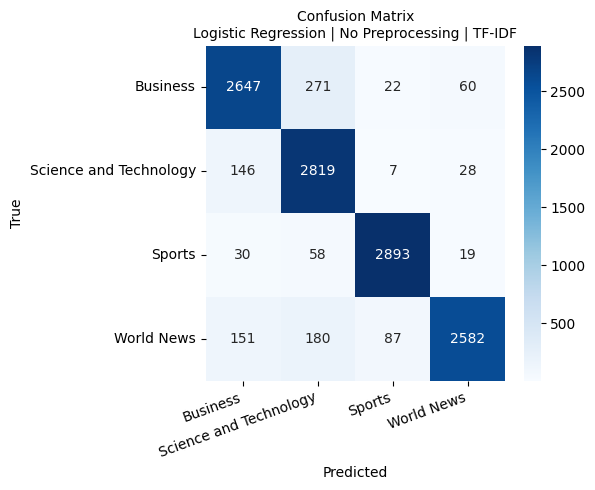


Model         : Logistic Regression
Preprocessing : Extreme Preprocessing
Representation: TF-IDF
Accuracy      : 0.8993
Macro F1      : 0.8996
Classification Report:
                        precision    recall  f1-score   support

              Business       0.84      0.90      0.87      3000
Science and Technology       0.89      0.88      0.88      3000
                Sports       0.95      0.96      0.96      3000
            World News       0.93      0.87      0.90      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



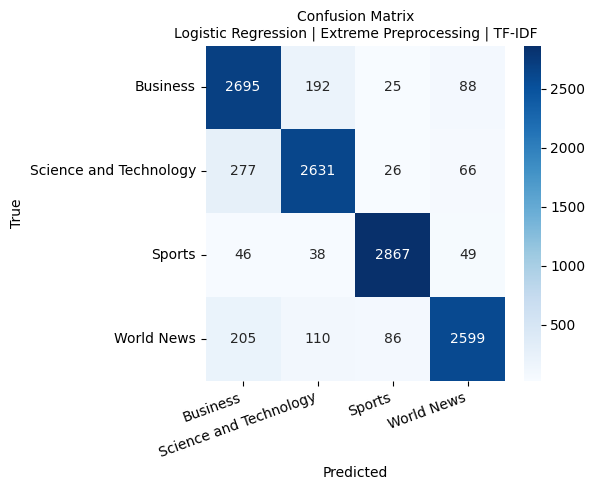


Model         : Logistic Regression
Preprocessing : Optimum Preprocessing
Representation: TF-IDF
Accuracy      : 0.9204
Macro F1      : 0.9205
Classification Report:
                        precision    recall  f1-score   support

              Business       0.87      0.91      0.89      3000
Science and Technology       0.91      0.90      0.90      3000
                Sports       0.96      0.97      0.97      3000
            World News       0.94      0.90      0.92      3000

              accuracy                           0.92     12000
             macro avg       0.92      0.92      0.92     12000
          weighted avg       0.92      0.92      0.92     12000



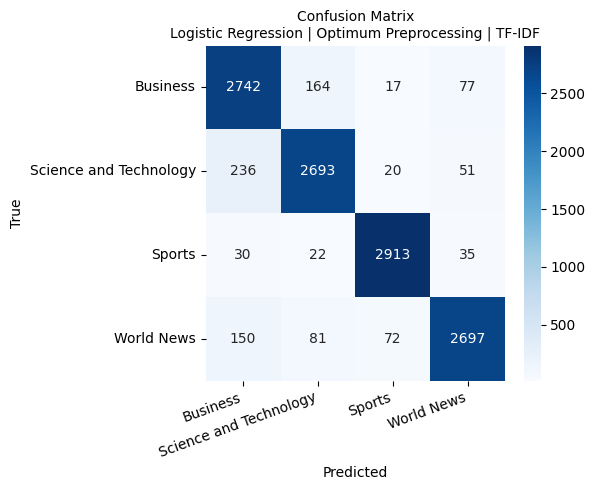

(0.9204166666666667, 0.9205426609760414)

In [ ]:
# No Preprocessing
logreg_model_raw = LogisticRegression(
    C=1.0,
    solver='saga',
    multi_class='multinomial',
    max_iter=500,
    random_state=42,
    n_jobs=-1
)

logreg_model_raw.fit(X_train_tfidf_raw, y_train)
y_pred_logreg_raw = logreg_model_raw.predict(X_test_tfidf_raw)

evaluate_model(
    'Logistic Regression',
    'No Preprocessing',
    'TF-IDF',
    y_test,
    y_pred_logreg_raw
)


# Extreme Preprocessing
logreg_model_extreme = LogisticRegression(
    C=1.0,
    solver='saga',
    multi_class='multinomial',
    max_iter=500,
    random_state=42,
    n_jobs=-1
)

logreg_model_extreme.fit(X_train_tfidf_extreme, y_train)
y_pred_logreg_extreme = logreg_model_extreme.predict(X_test_tfidf_extreme)

evaluate_model(
    'Logistic Regression',
    'Extreme Preprocessing',
    'TF-IDF',
    y_test,
    y_pred_logreg_extreme
)


# Optimum Preprocessing
logreg_model_optimum = LogisticRegression(
    C=1.0,
    solver='saga',
    multi_class='multinomial',
    max_iter=500,
    random_state=42,
    n_jobs=-1
)

logreg_model_optimum.fit(X_train_tfidf_optimum, y_train)
y_pred_logreg_optimum = logreg_model_optimum.predict(X_test_tfidf_optimum)

evaluate_model(
    'Logistic Regression',
    'Optimum Preprocessing',
    'TF-IDF',
    y_test,
    y_pred_logreg_optimum
)

## Deep Neural Network — TF-IDF Input


=== DNN: No Preprocessing ===


Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │    25,600,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,777,092 (98.33 MB)

 Trainable params: 25,775,172 (98.32 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/20  loss=0.9198  acc=0.6758  val_loss=0.5685  val_acc=0.8115
Epoch 2/20  loss=0.4683  acc=0.8476  val_loss=0.3940  val_acc=0.8732
Epoch 3/20  loss=0.3408  acc=0.8910  val_loss=0.2981  val_acc=0.9049
Epoch 4/20  loss=0.2659  acc=0.9153  val_loss=0.2409  val_acc=0.9236
Epoch 5/20  loss=0.2208  acc=0.9303  val_loss=0.2049  val_acc=0.9359
Epoch 6/20  loss=0.1919  acc=0.9403  val_loss=0.1812  val_acc=0.9441
Epoch 7/20  loss=0.1717  acc=0.9474  val_loss=0.1640  val_acc=0.9502
Epoch 8/20  loss=0.1569  acc=0.9526  val_loss=0.1510  val_acc=0.9547
Epoch 9/20  loss=0.1455  acc=0.9567  val_loss=0.1409  val_acc=0.9584
Epoch 10/20  loss=0.1365  acc=0.9600  val_loss=0.1328  val_acc=0.9614
Epoch 11/20  loss=0.1292  acc=0.9627  val_loss=0.1262  val_acc=0.9638
Epoch 12/20  loss=0.1232  acc=0.9649  val_loss=0.1207  val_acc=0.9658
Epoch 13/20  loss=0.1182  acc=0.9667  val_loss=0.1161  val_acc=0.9675
Epoch 14/20  loss=0.1139  acc=0.9683  val_loss=0.1121  val_acc=0.9690
Epoch 15/20  loss=0.1103  acc

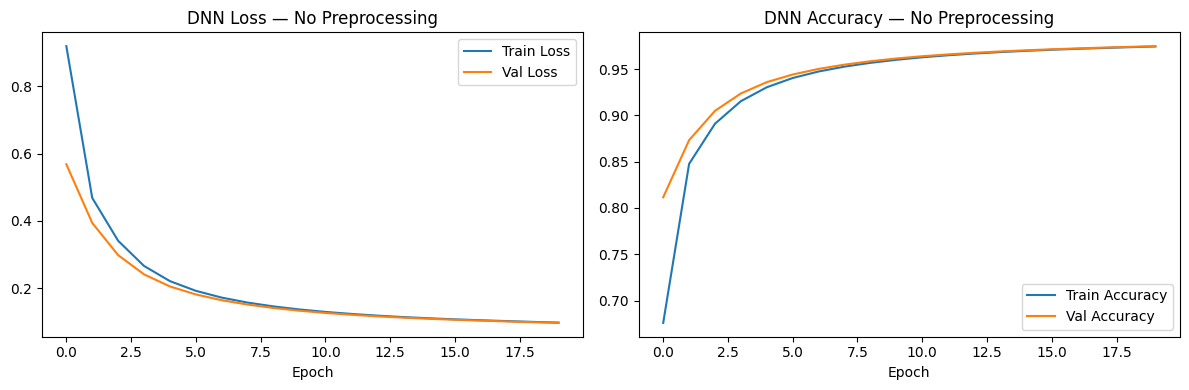


Model         : Deep Neural Network
Preprocessing : No Preprocessing
Representation: TF-IDF
Accuracy      : 0.8742
Macro F1      : 0.8756
Classification Report:
                        precision    recall  f1-score   support

              Business       0.91      0.79      0.85      3000
Science and Technology       0.74      0.95      0.83      3000
                Sports       0.96      0.94      0.95      3000
            World News       0.95      0.81      0.87      3000

              accuracy                           0.87     12000
             macro avg       0.89      0.87      0.88     12000
          weighted avg       0.89      0.87      0.88     12000



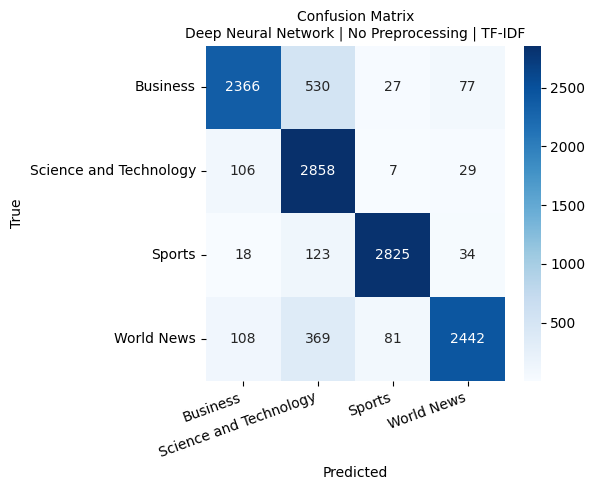


=== DNN: Extreme Preprocessing ===


Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │    25,600,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,777,092 (98.33 MB)

 Trainable params: 25,775,172 (98.32 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/20  loss=0.9621  acc=0.6528  val_loss=0.6182  val_acc=0.7932
Epoch 2/20  loss=0.5131  acc=0.8319  val_loss=0.4383  val_acc=0.8583
Epoch 3/20  loss=0.3827  acc=0.8772  val_loss=0.3390  val_acc=0.8916
Epoch 4/20  loss=0.3038  acc=0.9029  val_loss=0.2773  val_acc=0.9119
Epoch 5/20  loss=0.2547  acc=0.9194  val_loss=0.2373  val_acc=0.9256
Epoch 6/20  loss=0.2225  acc=0.9307  val_loss=0.2106  val_acc=0.9350
Epoch 7/20  loss=0.2001  acc=0.9387  val_loss=0.1915  val_acc=0.9418
Epoch 8/20  loss=0.1834  acc=0.9446  val_loss=0.1769  val_acc=0.9471
Epoch 9/20  loss=0.1707  acc=0.9493  val_loss=0.1657  val_acc=0.9512
Epoch 10/20  loss=0.1608  acc=0.9529  val_loss=0.1568  val_acc=0.9545
Epoch 11/20  loss=0.1528  acc=0.9559  val_loss=0.1497  val_acc=0.9571
Epoch 12/20  loss=0.1464  acc=0.9583  val_loss=0.1437  val_acc=0.9594
Epoch 13/20  loss=0.1409  acc=0.9604  val_loss=0.1387  val_acc=0.9613
Epoch 14/20  loss=0.1364  acc=0.9621  val_loss=0.1345  val_acc=0.9629
Epoch 15/20  loss=0.1325  acc

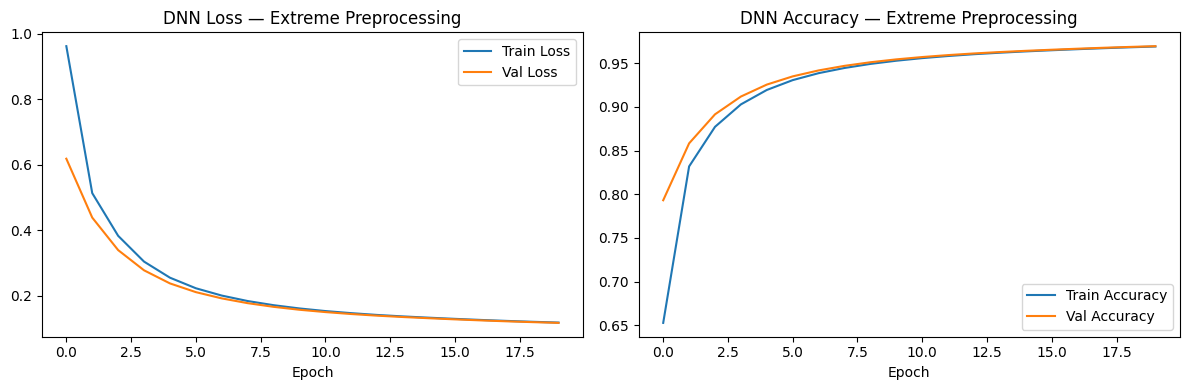


Model         : Deep Neural Network
Preprocessing : Extreme Preprocessing
Representation: TF-IDF
Accuracy      : 0.8820
Macro F1      : 0.8819
Classification Report:
                        precision    recall  f1-score   support

              Business       0.86      0.83      0.85      3000
Science and Technology       0.85      0.88      0.86      3000
                Sports       0.94      0.95      0.94      3000
            World News       0.88      0.87      0.88      3000

              accuracy                           0.88     12000
             macro avg       0.88      0.88      0.88     12000
          weighted avg       0.88      0.88      0.88     12000



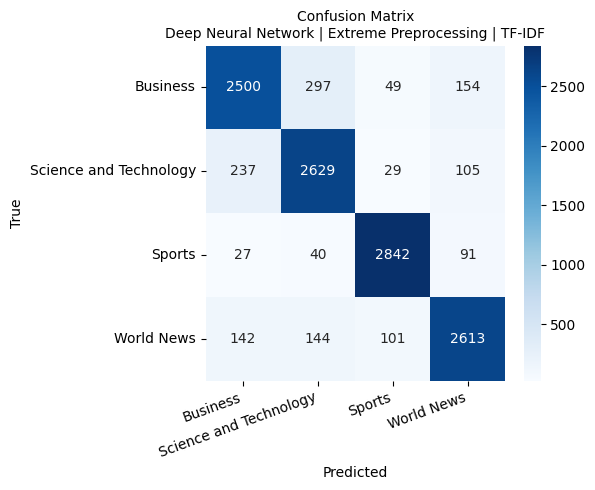


=== DNN: Optimum Preprocessing ===


Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │    25,600,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,777,092 (98.33 MB)

 Trainable params: 25,775,172 (98.32 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/20  loss=0.9273  acc=0.6654  val_loss=0.5673  val_acc=0.8020
Epoch 2/20  loss=0.4670  acc=0.8370  val_loss=0.3935  val_acc=0.8649
Epoch 3/20  loss=0.3420  acc=0.8836  val_loss=0.3003  val_acc=0.8985
Epoch 4/20  loss=0.2680  acc=0.9097  val_loss=0.2432  val_acc=0.9187
Epoch 5/20  loss=0.2232  acc=0.9257  val_loss=0.2073  val_acc=0.9316
Epoch 6/20  loss=0.1937  acc=0.9365  val_loss=0.1829  val_acc=0.9406
Epoch 7/20  loss=0.1733  acc=0.9441  val_loss=0.1655  val_acc=0.9471
Epoch 8/20  loss=0.1581  acc=0.9498  val_loss=0.1522  val_acc=0.9522
Epoch 9/20  loss=0.1465  acc=0.9543  val_loss=0.1418  val_acc=0.9561
Epoch 10/20  loss=0.1372  acc=0.9578  val_loss=0.1335  val_acc=0.9593
Epoch 11/20  loss=0.1297  acc=0.9607  val_loss=0.1267  val_acc=0.9619
Epoch 12/20  loss=0.1236  acc=0.9630  val_loss=0.1212  val_acc=0.9640
Epoch 13/20  loss=0.1186  acc=0.9650  val_loss=0.1165  val_acc=0.9658
Epoch 14/20  loss=0.1144  acc=0.9666  val_loss=0.1126  val_acc=0.9673
Epoch 15/20  loss=0.1107  acc

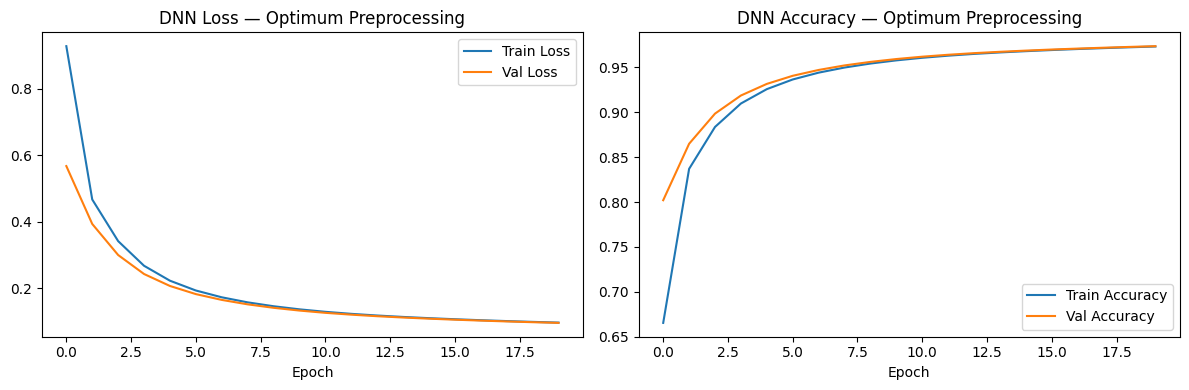


Model         : Deep Neural Network
Preprocessing : Optimum Preprocessing
Representation: TF-IDF
Accuracy      : 0.9039
Macro F1      : 0.9039
Classification Report:
                        precision    recall  f1-score   support

              Business       0.89      0.85      0.87      3000
Science and Technology       0.86      0.91      0.88      3000
                Sports       0.96      0.96      0.96      3000
            World News       0.91      0.90      0.90      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



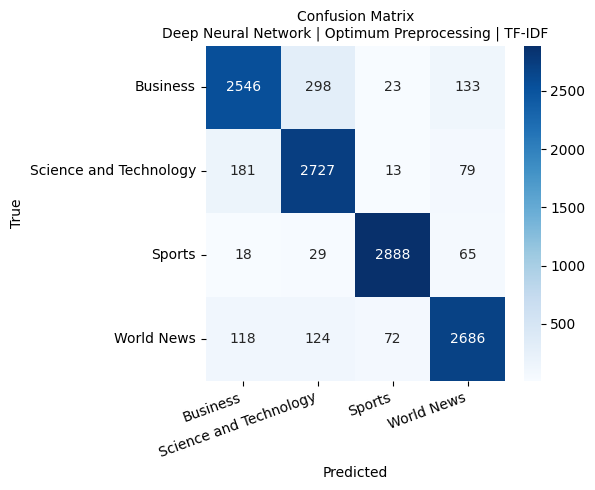

In [ ]:
# Architecture: 4 FC layers [512→256→128→64] with BatchNorm + Dropout
# Hyperparameters: dropout=0.4, lr=1e-3, batch_size=512, Adam optimizer

def build_dnn(input_dim, num_classes=4, units=[512, 256, 128, 64],
              dropout_rate=0.4, learning_rate=1e-3):

    model = Sequential(name='DNN')
    model.add(Input(shape=(input_dim,), name='tfidf_input'))

    for unit_size in units:
        model.add(Dense(unit_size, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


CALLBACKS = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
]


def predict_sparse_batches(model, X_sparse_matrix, batch_size=1024):
    num_samples = X_sparse_matrix.shape[0]
    predictions = []

    for start_idx in range(0, num_samples, batch_size):
        batch_x = X_sparse_matrix[start_idx:start_idx + batch_size].toarray().astype("float32")
        batch_pred = np.argmax(model.predict(batch_x, verbose=0), axis=1)
        predictions.append(batch_pred)
        del batch_x

    return np.concatenate(predictions)


def train_dnn_model(X_train, X_test, y_train, y_test, preprocessing_label,
                    epochs=20, batch_size=512):

    import gc

    num_train = X_train.shape[0]
    input_dim = X_train.shape[1]

    val_split = max(1, int(0.1 * num_train))
    train_indices = np.arange(num_train - val_split)
    val_indices   = np.arange(num_train - val_split, num_train)

    model = build_dnn(input_dim)
    model.summary()

    best_val_loss = float("inf")
    best_weights = None

    patience_counter = 0
    lr_counter = 0
    patience = 3
    lr_patience = 2
    current_lr = 1e-3

    train_loss_history, val_loss_history = [], []
    train_acc_history, val_acc_history = [], []

    for epoch in range(epochs):

        np.random.shuffle(train_indices)

        epoch_loss, epoch_acc, num_batches = 0.0, 0.0, 0

        for start in range(0, len(train_indices), batch_size):
            batch_idx = train_indices[start:start + batch_size]

            x_batch = X_train[batch_idx].toarray().astype("float32")
            y_batch = y_train[batch_idx]

            loss, acc = model.train_on_batch(x_batch, y_batch)

            epoch_loss += loss
            epoch_acc += acc
            num_batches += 1

            del x_batch, y_batch

        epoch_loss /= num_batches
        epoch_acc /= num_batches

        val_loss, val_acc, val_batches = 0.0, 0.0, 0

        for start in range(0, len(val_indices), batch_size):
            batch_idx = val_indices[start:start + batch_size]

            x_val = X_train[batch_idx].toarray().astype("float32")
            y_val = y_train[batch_idx]

            vl, va = model.test_on_batch(x_val, y_val)

            val_loss += vl
            val_acc += va
            val_batches += 1

            del x_val, y_val

        val_loss /= val_batches
        val_acc /= val_batches

        train_loss_history.append(epoch_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(epoch_acc)
        val_acc_history.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}  loss={epoch_loss:.4f}  acc={epoch_acc:.4f}  "
              f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_weights = model.get_weights()
            patience_counter = 0
            lr_counter = 0
        else:
            patience_counter += 1
            lr_counter += 1

            if lr_counter >= lr_patience:
                current_lr = max(current_lr * 0.5, 1e-5)
                model.optimizer.learning_rate.assign(current_lr)
                print(f"  ReduceLR → lr={current_lr:.2e}")
                lr_counter = 0

            if patience_counter >= patience:
                print(f"  EarlyStopping at epoch {epoch+1}")
                break

    if best_weights is not None:
        model.set_weights(best_weights)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(train_loss_history, label='Train Loss')
    axes[0].plot(val_loss_history, label='Val Loss')
    axes[0].set_title(f'DNN Loss — {preprocessing_label}')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(train_acc_history, label='Train Accuracy')
    axes[1].plot(val_acc_history, label='Val Accuracy')
    axes[1].set_title(f'DNN Accuracy — {preprocessing_label}')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    y_pred = predict_sparse_batches(model, X_test, batch_size=1024)

    evaluate_model(
        'Deep Neural Network',
        preprocessing_label,
        'TF-IDF',
        y_test,
        y_pred
    )

    del model, best_weights
    gc.collect()
    tf.keras.backend.clear_session()


print('\n=== DNN: No Preprocessing ===')
train_dnn_model(X_train_tfidf_raw, X_test_tfidf_raw, y_train, y_test, 'No Preprocessing')

print('\n=== DNN: Extreme Preprocessing ===')
train_dnn_model(X_train_tfidf_extreme, X_test_tfidf_extreme, y_train, y_test, 'Extreme Preprocessing')

print('\n=== DNN: Optimum Preprocessing ===')
train_dnn_model(X_train_tfidf_optimum, X_test_tfidf_optimum, y_train, y_test, 'Optimum Preprocessing')

## RNN Model Builder & Trainer (Skip-gram Embeddings)
#### SimpleRNN, GRU, LSTM + Bidirectional versions
#### Common hyperparameters:
#### embed_dim=128,
#### rnn_units=128,
#### dropout=0.3,
#### batch_size=256,
#### lr=1e-3,
#### epochs=15


In [ ]:
# All 6 architectures:
def build_rnn_model(rnn_type, vocab_size, embedding_matrix,
                    max_len=max_sequence_length, rnn_units=128,
                    dropout_rate=0.3, num_classes=4, learning_rate=1e-3,
                    bidirectional=False):

    rnn_layer_map = {
        'SimpleRNN': SimpleRNN,
        'GRU': GRU,
        'LSTM': LSTM
    }

    rnn_layer_class = rnn_layer_map[rnn_type]

    model = Sequential(name=f"{'Bi' if bidirectional else ''}{rnn_type}")

    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False,
        name='skipgram_embedding'
    ))

    rnn_layer = rnn_layer_class(
        rnn_units,
        dropout=dropout_rate,
        recurrent_dropout=0.1
    )

    if bidirectional:
        rnn_layer = Bidirectional(rnn_layer)

    model.add(rnn_layer)

    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


def train_rnn_model(rnn_type, bidirectional_flag,
                    X_train_seq, X_test_seq, y_train_labels, y_test_labels,
                    vocab_size, embedding_matrix, preprocessing_label):

    import gc

    model_name = f"{'Bidirectional ' if bidirectional_flag else ''}{rnn_type}"
    print(f'\n=== {model_name} | {preprocessing_label} ===')

    model = build_rnn_model(
        rnn_type,
        vocab_size,
        embedding_matrix,
        bidirectional=bidirectional_flag
    )

    model.summary()

    history = model.fit(
        X_train_seq,
        y_train_labels,
        validation_split=0.1,
        epochs=15,
        batch_size=256,
        callbacks=CALLBACKS,
        verbose=1
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['loss'], label='Train')
    axes[0].plot(history.history['val_loss'], label='Val')
    axes[0].set_title(f'{model_name} Loss — {preprocessing_label}')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Train')
    axes[1].plot(history.history['val_accuracy'], label='Val')
    axes[1].set_title(f'{model_name} Accuracy — {preprocessing_label}')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    y_pred = np.argmax(model.predict(X_test_seq, verbose=0), axis=1)

    evaluate_model(
        model_name,
        preprocessing_label,
        'Skip-gram',
        y_test_labels,
        y_pred
    )

    del model, history
    gc.collect()
    tf.keras.backend.clear_session()


print('RNN builder and trainer defined.')

RNN builder and trainer defined.


## Train all 6 RNN models × 3 preprocessing variants = 18 experiments


=== SimpleRNN | No Preprocessing ===


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     7,571,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,571,072 (28.88 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 7,571,072 (28.88 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.3820 - loss: 1.3223 - val_accuracy: 0.3878 - val_loss: 1.3184 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4251 - loss: 1.2583 - val_accuracy: 0.3877 - val_loss: 1.3363 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3901 - loss: 1.3345 - val_accuracy: 0.3877 - val_loss: 1.3363 - learning_rate: 0.0010
Epoch 4/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3901 - loss: 1.3330 - val_accuracy: 0.3877 - val_loss: 1.3316 - learning_rate: 5.0000e-04


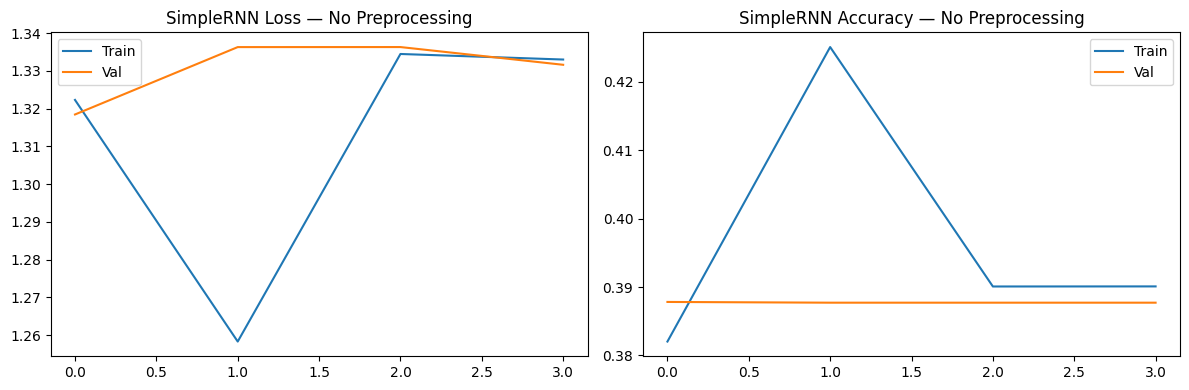


Model         : SimpleRNN
Preprocessing : No Preprocessing
Representation: Skip-gram
Accuracy      : 0.2500
Macro F1      : 0.1000
Classification Report:
                        precision    recall  f1-score   support

              Business       0.25      1.00      0.40      3000
Science and Technology       0.00      0.00      0.00      3000
                Sports       0.00      0.00      0.00      3000
            World News       0.00      0.00      0.00      3000

              accuracy                           0.25     12000
             macro avg       0.06      0.25      0.10     12000
          weighted avg       0.06      0.25      0.10     12000



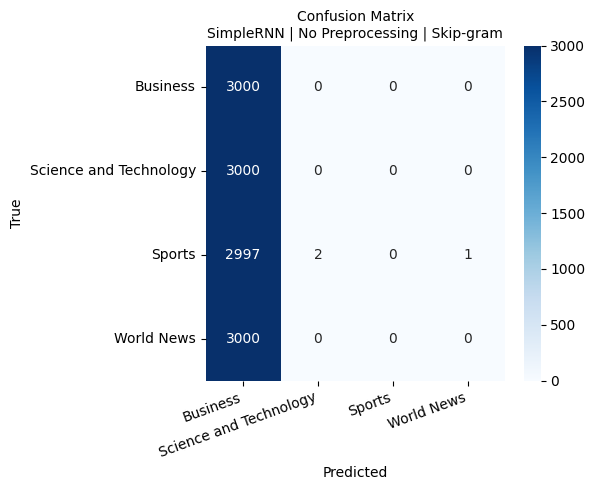


=== GRU | No Preprocessing ===


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     7,571,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,571,072 (28.88 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 7,571,072 (28.88 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 71s 189ms/step - accuracy: 0.6894 - loss: 0.7661 - val_accuracy: 0.8521 - val_loss: 0.4261 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 62s 189ms/step - accuracy: 0.8394 - loss: 0.4637 - val_accuracy: 0.8628 - val_loss: 0.3845 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 62s 188ms/step - accuracy: 0.8520 - loss: 0.4288 - val_accuracy: 0.8720 - val_loss: 0.3650 - learning_rate: 0.0010
Epoch 4/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 61s 186ms/step - accuracy: 0.8581 - loss: 0.4064 - val_accuracy: 0.8747 - val_loss: 0.3539 - learning_rate: 0.0010
Epoch 5/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 72s 218ms/step - accuracy: 0.8645 - loss: 0.3902 - val_accuracy: 0.8793 - val_loss: 0.3422 - learning_rate: 0.0010
Epoch 6/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 62s 189ms/step - accuracy: 0.8676 - loss: 0.3771 - val_accuracy: 0.8797 - val_loss: 0.3352 - learning_rate: 0.0010
Epoch 7/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 63s 193ms/step - accuracy: 0.8

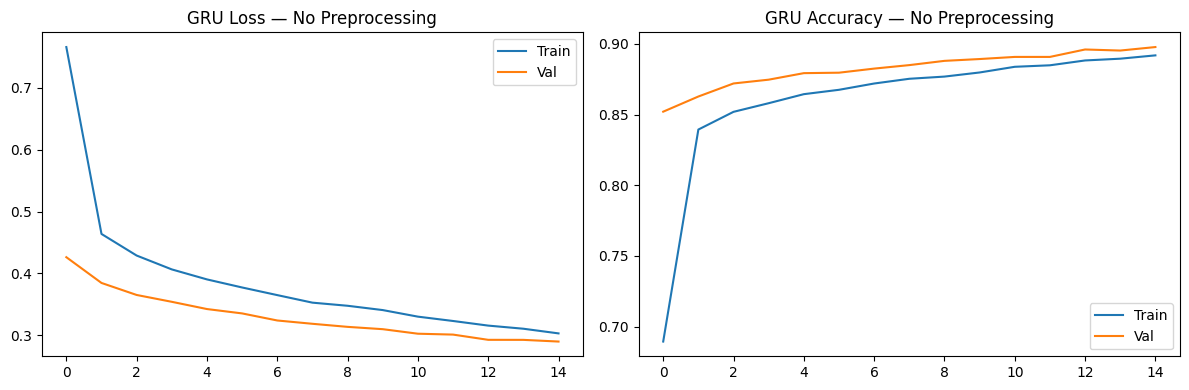


Model         : GRU
Preprocessing : No Preprocessing
Representation: Skip-gram
Accuracy      : 0.8953
Macro F1      : 0.8954
Classification Report:
                        precision    recall  f1-score   support

              Business       0.84      0.89      0.86      3000
Science and Technology       0.88      0.87      0.87      3000
                Sports       0.95      0.96      0.96      3000
            World News       0.92      0.87      0.89      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



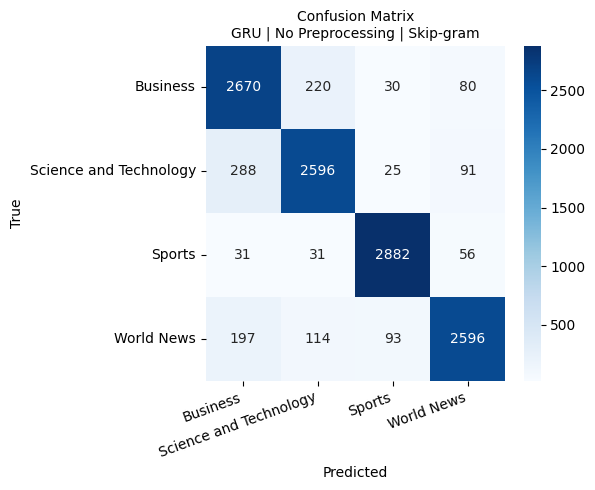


=== LSTM | No Preprocessing ===


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     7,571,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,571,072 (28.88 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 7,571,072 (28.88 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 75s 216ms/step - accuracy: 0.7449 - loss: 0.6873 - val_accuracy: 0.8485 - val_loss: 0.4609 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 72s 220ms/step - accuracy: 0.8271 - loss: 0.5094 - val_accuracy: 0.8652 - val_loss: 0.3929 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 71s 215ms/step - accuracy: 0.8428 - loss: 0.4546 - val_accuracy: 0.8657 - val_loss: 0.3809 - learning_rate: 5.0000e-04


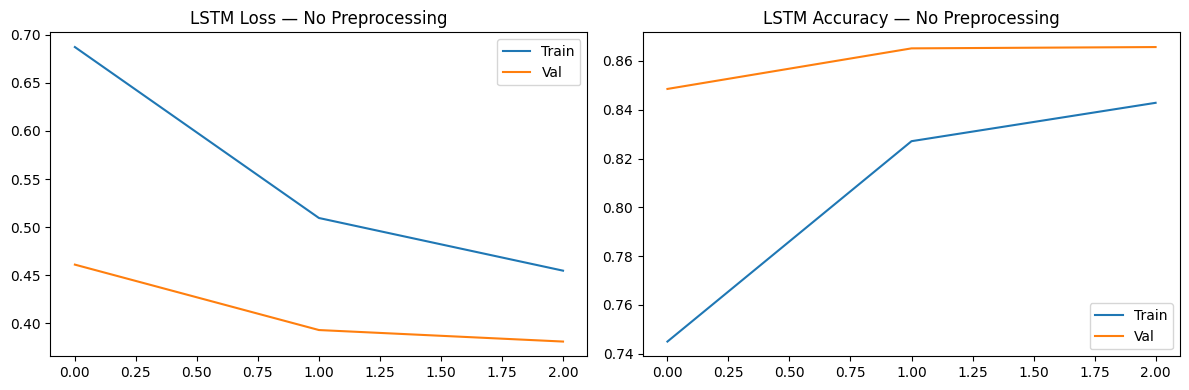


Model         : LSTM
Preprocessing : No Preprocessing
Representation: Skip-gram
Accuracy      : 0.8568
Macro F1      : 0.8570
Classification Report:
                        precision    recall  f1-score   support

              Business       0.81      0.82      0.82      3000
Science and Technology       0.82      0.83      0.83      3000
                Sports       0.92      0.92      0.92      3000
            World News       0.87      0.86      0.86      3000

              accuracy                           0.86     12000
             macro avg       0.86      0.86      0.86     12000
          weighted avg       0.86      0.86      0.86     12000



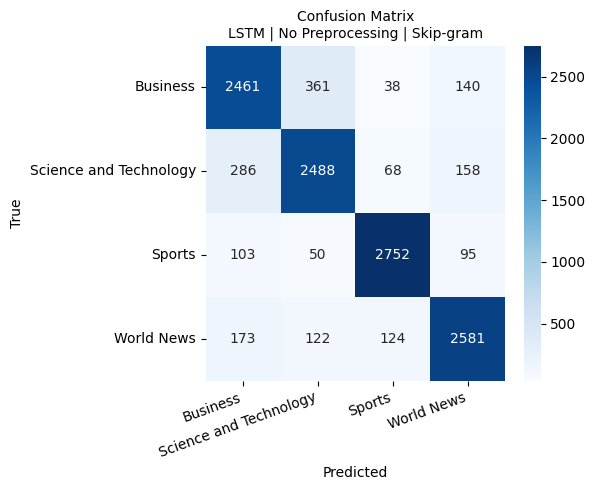


=== Bidirectional SimpleRNN | No Preprocessing ===


Model: "BiSimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     7,571,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,571,072 (28.88 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 7,571,072 (28.88 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.4945 - loss: 1.1393 - val_accuracy: 0.6342 - val_loss: 0.9317 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5742 - loss: 1.0353 - val_accuracy: 0.5158 - val_loss: 1.1713 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4836 - loss: 1.1774 - val_accuracy: 0.4468 - val_loss: 1.2348 - learning_rate: 5.0000e-04


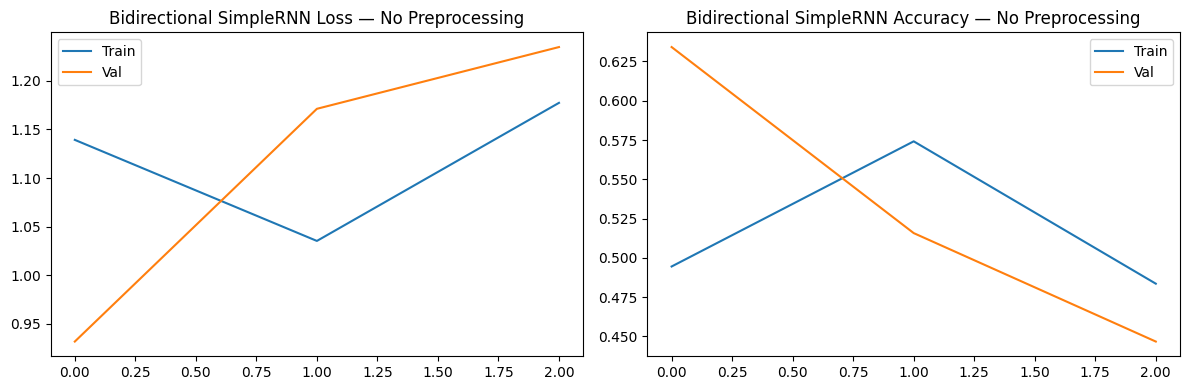


Model         : Bidirectional SimpleRNN
Preprocessing : No Preprocessing
Representation: Skip-gram
Accuracy      : 0.5786
Macro F1      : 0.5156
Classification Report:
                        precision    recall  f1-score   support

              Business       0.74      0.78      0.76      3000
Science and Technology       0.75      0.65      0.69      3000
                Sports       0.69      0.02      0.04      3000
            World News       0.42      0.87      0.57      3000

              accuracy                           0.58     12000
             macro avg       0.65      0.58      0.52     12000
          weighted avg       0.65      0.58      0.52     12000



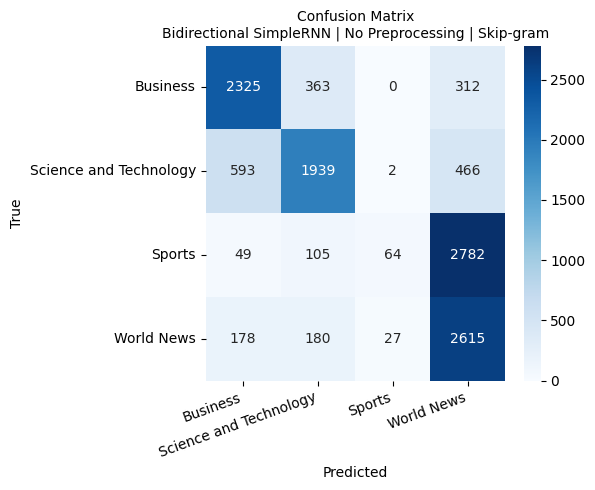


=== Bidirectional GRU | No Preprocessing ===


Model: "BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     7,571,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,571,072 (28.88 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 7,571,072 (28.88 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 118s 344ms/step - accuracy: 0.7408 - loss: 0.6672 - val_accuracy: 0.8514 - val_loss: 0.4350 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 113s 345ms/step - accuracy: 0.8476 - loss: 0.4437 - val_accuracy: 0.8682 - val_loss: 0.3762 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 140s 340ms/step - accuracy: 0.8588 - loss: 0.4069 - val_accuracy: 0.8730 - val_loss: 0.3539 - learning_rate: 5.0000e-04


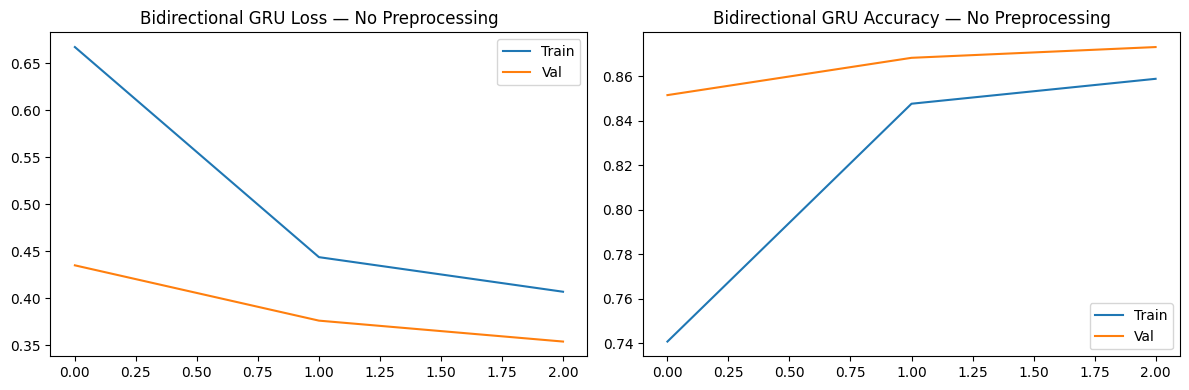


Model         : Bidirectional GRU
Preprocessing : No Preprocessing
Representation: Skip-gram
Accuracy      : 0.8526
Macro F1      : 0.8538
Classification Report:
                        precision    recall  f1-score   support

              Business       0.81      0.83      0.82      3000
Science and Technology       0.79      0.88      0.83      3000
                Sports       0.97      0.84      0.90      3000
            World News       0.87      0.86      0.86      3000

              accuracy                           0.85     12000
             macro avg       0.86      0.85      0.85     12000
          weighted avg       0.86      0.85      0.85     12000



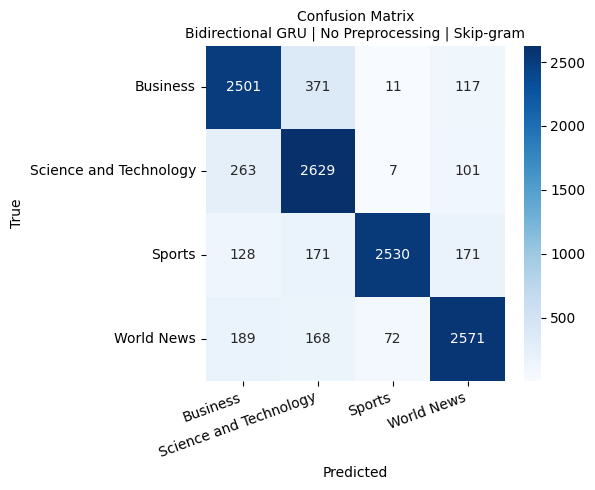


=== Bidirectional LSTM | No Preprocessing ===


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     7,571,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,571,072 (28.88 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 7,571,072 (28.88 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 129s 376ms/step - accuracy: 0.7733 - loss: 0.6076 - val_accuracy: 0.8547 - val_loss: 0.4070 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 122s 373ms/step - accuracy: 0.8404 - loss: 0.4585 - val_accuracy: 0.8672 - val_loss: 0.3756 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 121s 369ms/step - accuracy: 0.8545 - loss: 0.4162 - val_accuracy: 0.8733 - val_loss: 0.3584 - learning_rate: 5.0000e-04


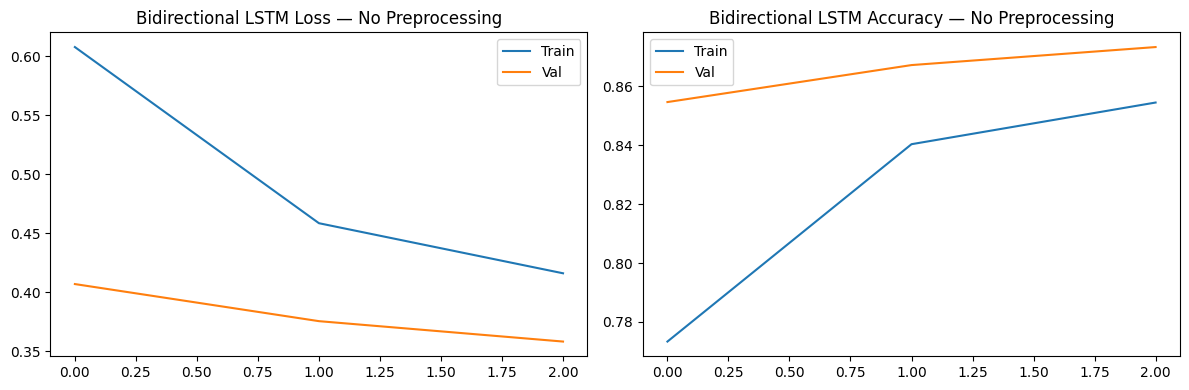


Model         : Bidirectional LSTM
Preprocessing : No Preprocessing
Representation: Skip-gram
Accuracy      : 0.8532
Macro F1      : 0.8543
Classification Report:
                        precision    recall  f1-score   support

              Business       0.74      0.90      0.81      3000
Science and Technology       0.86      0.80      0.83      3000
                Sports       0.93      0.92      0.93      3000
            World News       0.93      0.79      0.85      3000

              accuracy                           0.85     12000
             macro avg       0.86      0.85      0.85     12000
          weighted avg       0.86      0.85      0.85     12000



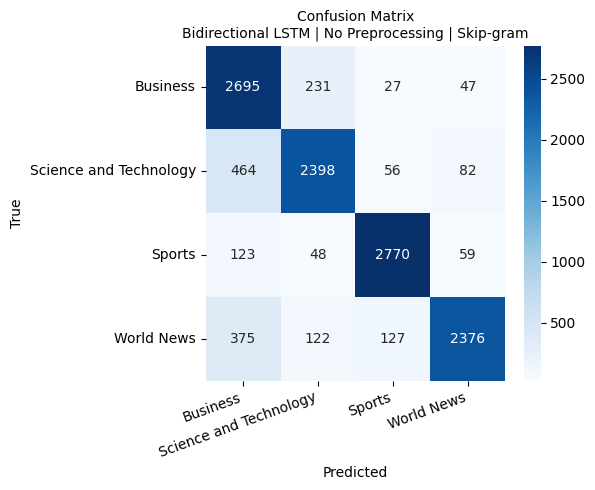


--- Finished all RNN models for: No Preprocessing ---


=== SimpleRNN | Extreme Preprocessing ===


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     3,530,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,530,496 (13.47 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,530,496 (13.47 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.4401 - loss: 1.2157 - val_accuracy: 0.3878 - val_loss: 1.3385 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3930 - loss: 1.3326 - val_accuracy: 0.3877 - val_loss: 1.3351 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3922 - loss: 1.3314 - val_accuracy: 0.3877 - val_loss: 1.3346 - learning_rate: 5.0000e-04


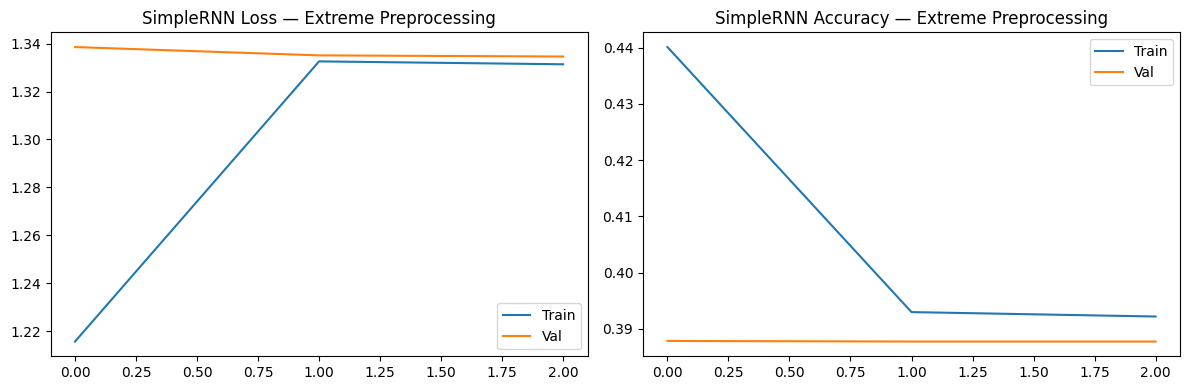


Model         : SimpleRNN
Preprocessing : Extreme Preprocessing
Representation: Skip-gram
Accuracy      : 0.2500
Macro F1      : 0.1000
Classification Report:
                        precision    recall  f1-score   support

              Business       0.25      1.00      0.40      3000
Science and Technology       0.00      0.00      0.00      3000
                Sports       0.00      0.00      0.00      3000
            World News       0.00      0.00      0.00      3000

              accuracy                           0.25     12000
             macro avg       0.06      0.25      0.10     12000
          weighted avg       0.06      0.25      0.10     12000



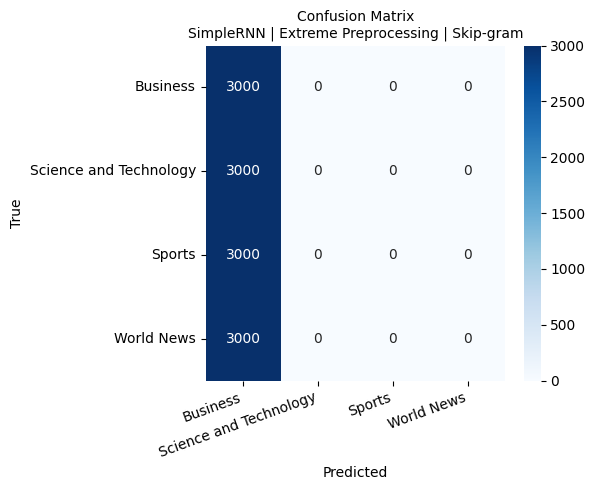


=== GRU | Extreme Preprocessing ===


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     3,530,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,530,496 (13.47 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,530,496 (13.47 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 69s 199ms/step - accuracy: 0.3905 - loss: 1.3355 - val_accuracy: 0.3880 - val_loss: 1.3336 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 63s 193ms/step - accuracy: 0.6888 - loss: 0.7642 - val_accuracy: 0.8756 - val_loss: 0.3663 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 64s 194ms/step - accuracy: 0.8615 - loss: 0.4123 - val_accuracy: 0.8810 - val_loss: 0.3466 - learning_rate: 5.0000e-04


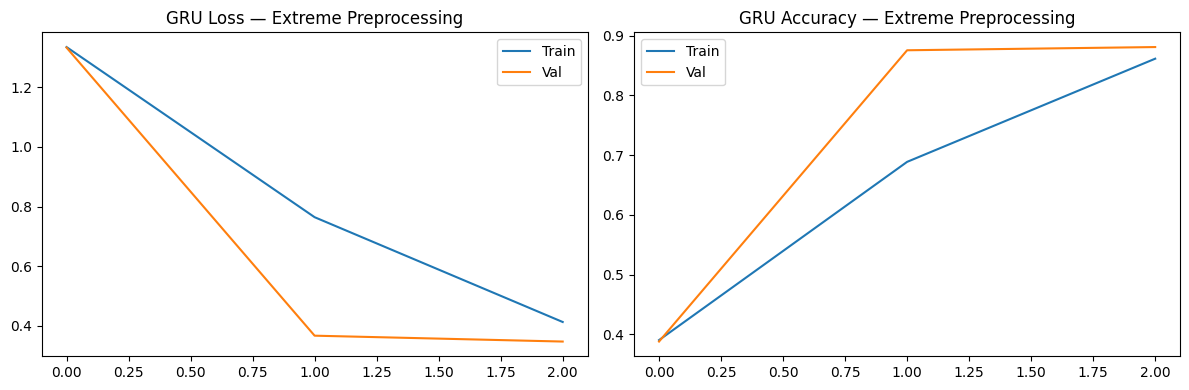


Model         : GRU
Preprocessing : Extreme Preprocessing
Representation: Skip-gram
Accuracy      : 0.2503
Macro F1      : 0.1007
Classification Report:
                        precision    recall  f1-score   support

              Business       0.25      1.00      0.40      3000
Science and Technology       1.00      0.00      0.00      3000
                Sports       0.00      0.00      0.00      3000
            World News       0.00      0.00      0.00      3000

              accuracy                           0.25     12000
             macro avg       0.31      0.25      0.10     12000
          weighted avg       0.31      0.25      0.10     12000



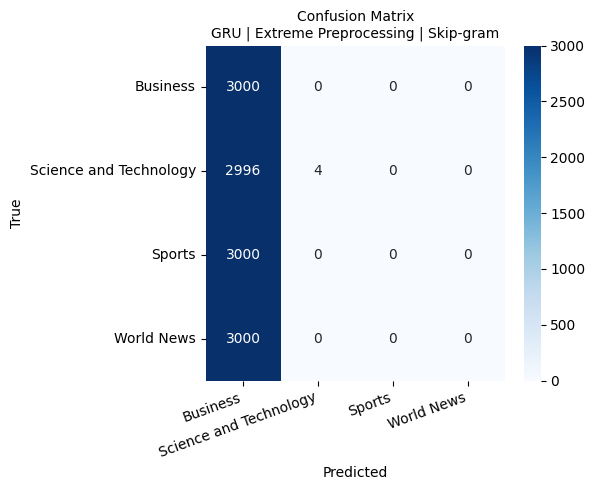


=== LSTM | Extreme Preprocessing ===


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     3,530,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,530,496 (13.47 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,530,496 (13.47 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 74s 213ms/step - accuracy: 0.7023 - loss: 0.7430 - val_accuracy: 0.8590 - val_loss: 0.4360 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 71s 216ms/step - accuracy: 0.8447 - loss: 0.4901 - val_accuracy: 0.8737 - val_loss: 0.3867 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 70s 214ms/step - accuracy: 0.8551 - loss: 0.4434 - val_accuracy: 0.8749 - val_loss: 0.3649 - learning_rate: 5.0000e-04


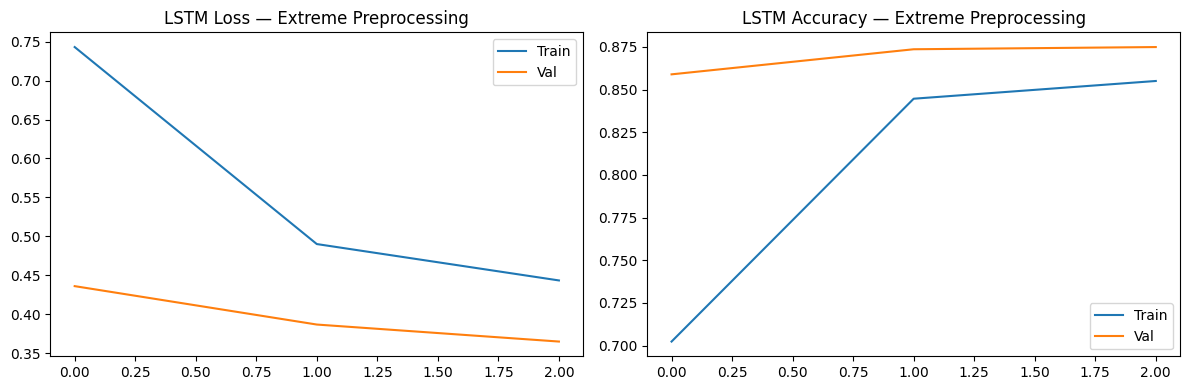


Model         : LSTM
Preprocessing : Extreme Preprocessing
Representation: Skip-gram
Accuracy      : 0.8545
Macro F1      : 0.8543
Classification Report:
                        precision    recall  f1-score   support

              Business       0.74      0.91      0.81      3000
Science and Technology       0.91      0.72      0.80      3000
                Sports       0.94      0.95      0.94      3000
            World News       0.88      0.83      0.86      3000

              accuracy                           0.85     12000
             macro avg       0.86      0.85      0.85     12000
          weighted avg       0.86      0.85      0.85     12000



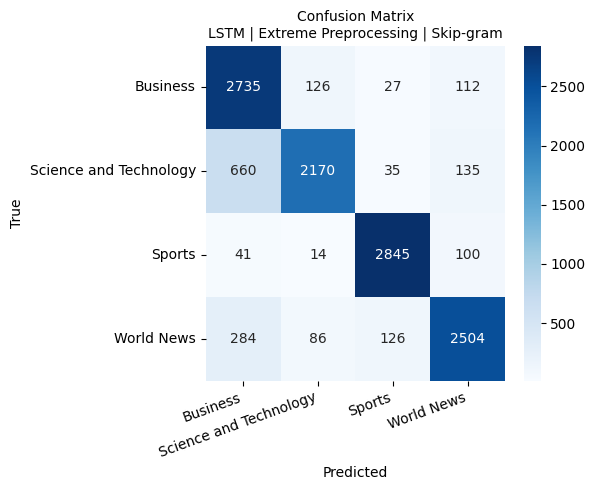


=== Bidirectional SimpleRNN | Extreme Preprocessing ===


Model: "BiSimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     3,530,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,530,496 (13.47 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,530,496 (13.47 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.7502 - loss: 0.6851 - val_accuracy: 0.8497 - val_loss: 0.4393 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8038 - loss: 0.5724 - val_accuracy: 0.8547 - val_loss: 0.4350 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8125 - loss: 0.5469 - val_accuracy: 0.8605 - val_loss: 0.4115 - learning_rate: 5.0000e-04


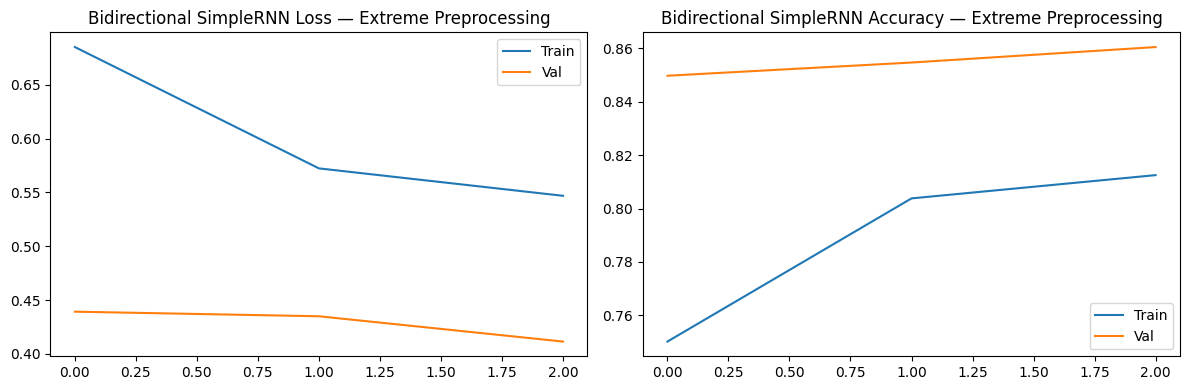


Model         : Bidirectional SimpleRNN
Preprocessing : Extreme Preprocessing
Representation: Skip-gram
Accuracy      : 0.8476
Macro F1      : 0.8484
Classification Report:
                        precision    recall  f1-score   support

              Business       0.78      0.85      0.81      3000
Science and Technology       0.77      0.85      0.81      3000
                Sports       0.94      0.92      0.93      3000
            World News       0.92      0.77      0.84      3000

              accuracy                           0.85     12000
             macro avg       0.85      0.85      0.85     12000
          weighted avg       0.85      0.85      0.85     12000



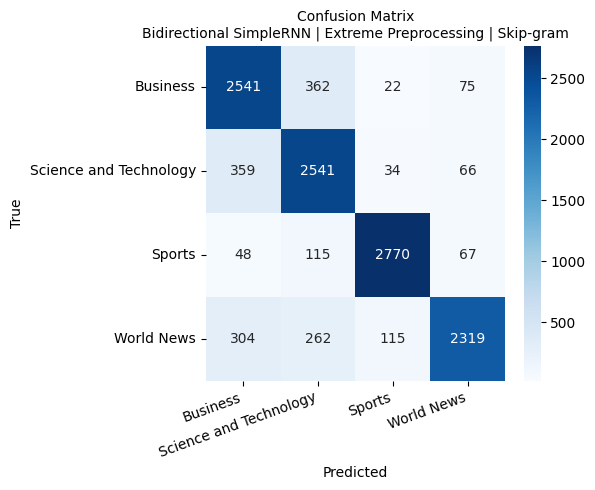


=== Bidirectional GRU | Extreme Preprocessing ===


Model: "BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     3,530,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,530,496 (13.47 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,530,496 (13.47 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 121s 351ms/step - accuracy: 0.8070 - loss: 0.5268 - val_accuracy: 0.8775 - val_loss: 0.3544 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 114s 346ms/step - accuracy: 0.8609 - loss: 0.4039 - val_accuracy: 0.8814 - val_loss: 0.3378 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 114s 347ms/step - accuracy: 0.8675 - loss: 0.3824 - val_accuracy: 0.8866 - val_loss: 0.3262 - learning_rate: 5.0000e-04


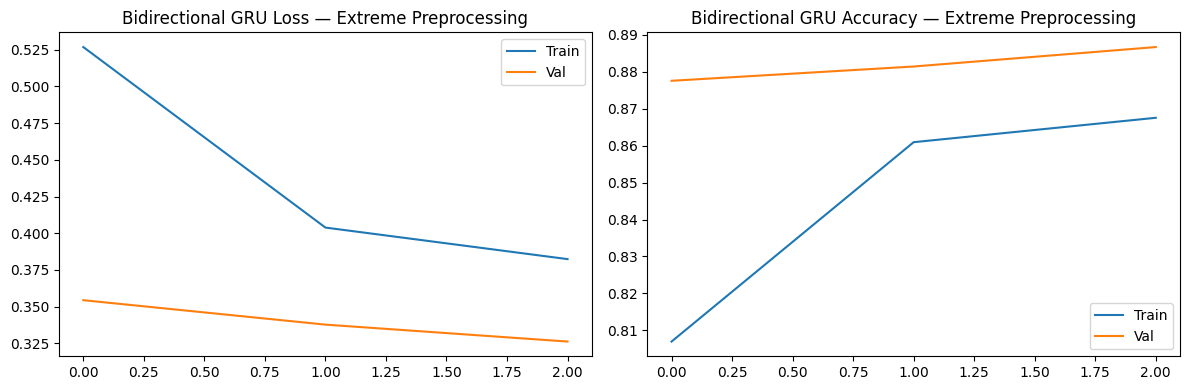


Model         : Bidirectional GRU
Preprocessing : Extreme Preprocessing
Representation: Skip-gram
Accuracy      : 0.8751
Macro F1      : 0.8757
Classification Report:
                        precision    recall  f1-score   support

              Business       0.78      0.89      0.83      3000
Science and Technology       0.86      0.83      0.85      3000
                Sports       0.95      0.95      0.95      3000
            World News       0.93      0.82      0.87      3000

              accuracy                           0.88     12000
             macro avg       0.88      0.88      0.88     12000
          weighted avg       0.88      0.88      0.88     12000



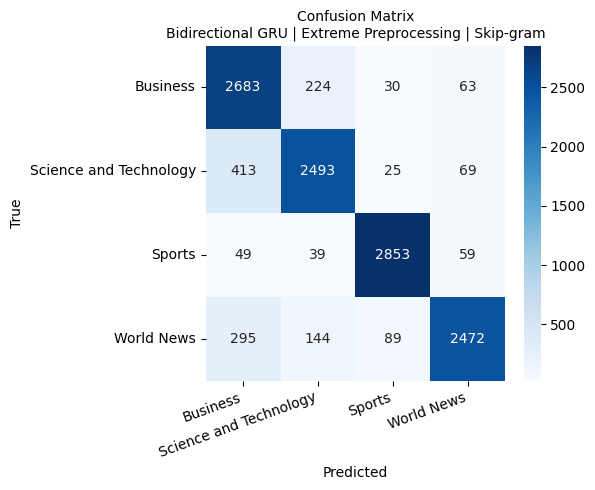


=== Bidirectional LSTM | Extreme Preprocessing ===


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     3,530,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,530,496 (13.47 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,530,496 (13.47 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 139s 403ms/step - accuracy: 0.8239 - loss: 0.5007 - val_accuracy: 0.8758 - val_loss: 0.3639 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 130s 396ms/step - accuracy: 0.8604 - loss: 0.4078 - val_accuracy: 0.8814 - val_loss: 0.3341 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 129s 394ms/step - accuracy: 0.8696 - loss: 0.3769 - val_accuracy: 0.8845 - val_loss: 0.3183 - learning_rate: 5.0000e-04


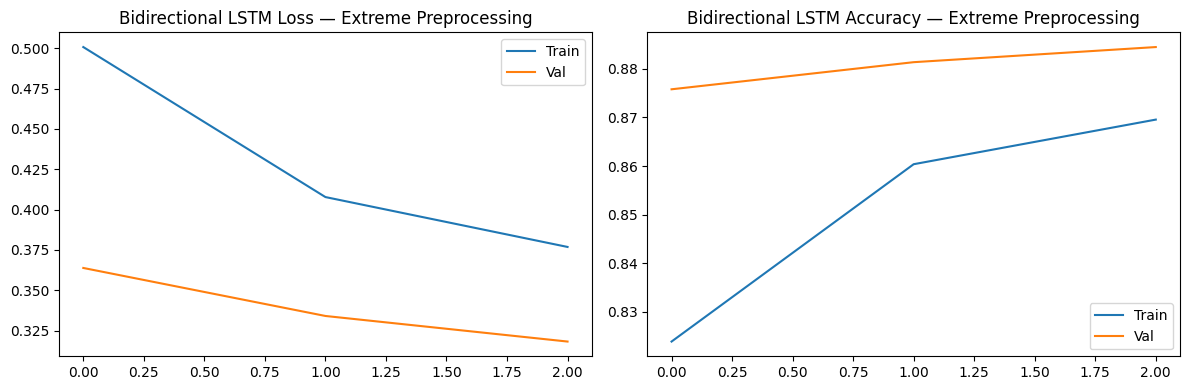


Model         : Bidirectional LSTM
Preprocessing : Extreme Preprocessing
Representation: Skip-gram
Accuracy      : 0.8736
Macro F1      : 0.8743
Classification Report:
                        precision    recall  f1-score   support

              Business       0.78      0.88      0.83      3000
Science and Technology       0.86      0.85      0.85      3000
                Sports       0.95      0.95      0.95      3000
            World News       0.93      0.82      0.87      3000

              accuracy                           0.87     12000
             macro avg       0.88      0.87      0.87     12000
          weighted avg       0.88      0.87      0.87     12000



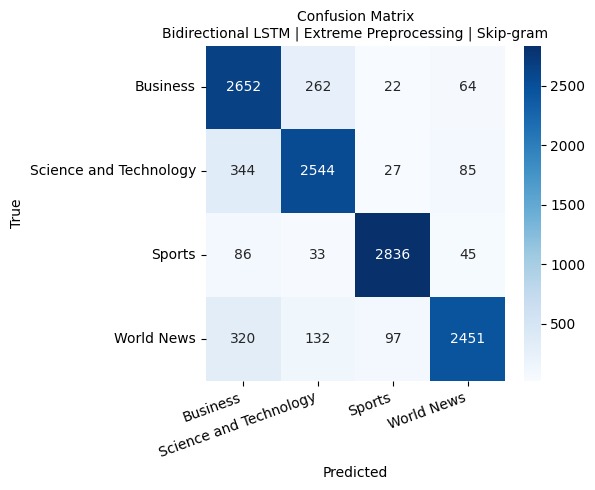


--- Finished all RNN models for: Extreme Preprocessing ---


=== SimpleRNN | Optimum Preprocessing ===


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     6,667,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,667,008 (25.43 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,667,008 (25.43 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.4088 - loss: 1.2975 - val_accuracy: 0.3877 - val_loss: 1.3342 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3901 - loss: 1.3347 - val_accuracy: 0.3877 - val_loss: 1.3337 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3901 - loss: 1.3337 - val_accuracy: 0.3877 - val_loss: 1.3337 - learning_rate: 5.0000e-04


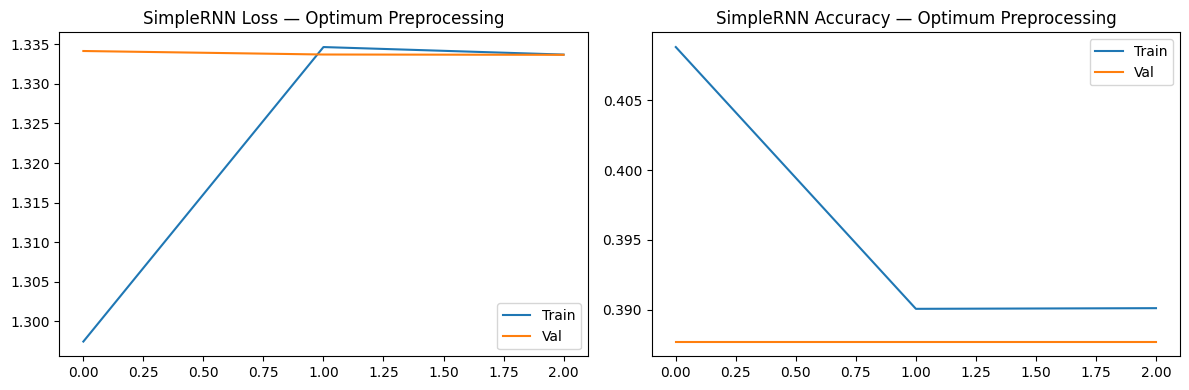


Model         : SimpleRNN
Preprocessing : Optimum Preprocessing
Representation: Skip-gram
Accuracy      : 0.2500
Macro F1      : 0.1000
Classification Report:
                        precision    recall  f1-score   support

              Business       0.25      1.00      0.40      3000
Science and Technology       0.00      0.00      0.00      3000
                Sports       0.00      0.00      0.00      3000
            World News       0.00      0.00      0.00      3000

              accuracy                           0.25     12000
             macro avg       0.06      0.25      0.10     12000
          weighted avg       0.06      0.25      0.10     12000



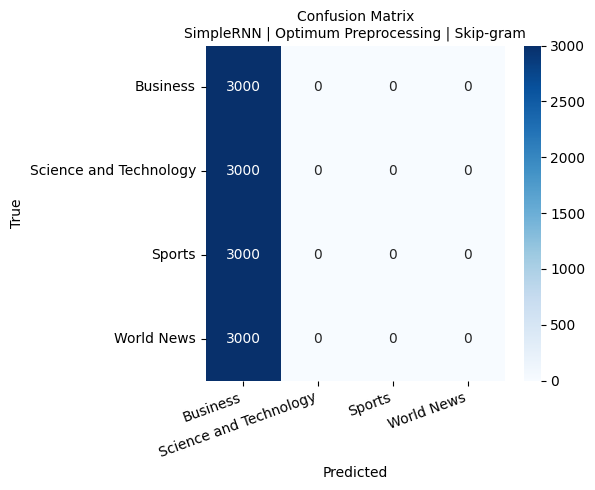


=== GRU | Optimum Preprocessing ===


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     6,667,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,667,008 (25.43 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,667,008 (25.43 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 75s 218ms/step - accuracy: 0.5757 - loss: 0.9195 - val_accuracy: 0.7614 - val_loss: 0.5293 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 78s 206ms/step - accuracy: 0.8668 - loss: 0.3898 - val_accuracy: 0.8985 - val_loss: 0.2925 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 81s 204ms/step - accuracy: 0.8863 - loss: 0.3346 - val_accuracy: 0.8985 - val_loss: 0.2861 - learning_rate: 5.0000e-04
Epoch 4/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 82s 203ms/step - accuracy: 0.8910 - loss: 0.3185 - val_accuracy: 0.9036 - val_loss: 0.2735 - learning_rate: 5.0000e-04
Epoch 5/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 82s 203ms/step - accuracy: 0.8937 - loss: 0.3121 - val_accuracy: 0.9074 - val_loss: 0.2649 - learning_rate: 5.0000e-04
Epoch 6/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 82s 204ms/step - accuracy: 0.8952 - loss: 0.3046 - val_accuracy: 0.9090 - val_loss: 0.2620 - learning_rate: 5.0000e-04
Epoch 7/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 67s 203ms/step

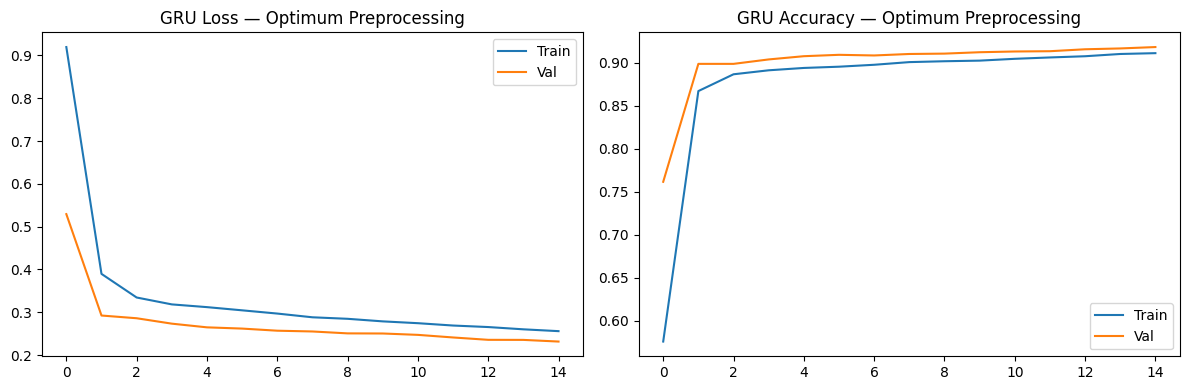


Model         : GRU
Preprocessing : Optimum Preprocessing
Representation: Skip-gram
Accuracy      : 0.9207
Macro F1      : 0.9207
Classification Report:
                        precision    recall  f1-score   support

              Business       0.88      0.91      0.89      3000
Science and Technology       0.90      0.91      0.90      3000
                Sports       0.96      0.98      0.97      3000
            World News       0.95      0.89      0.92      3000

              accuracy                           0.92     12000
             macro avg       0.92      0.92      0.92     12000
          weighted avg       0.92      0.92      0.92     12000



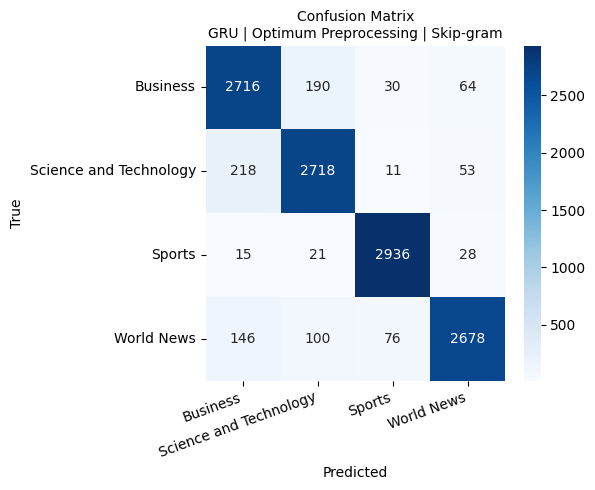


=== LSTM | Optimum Preprocessing ===


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     6,667,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,667,008 (25.43 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,667,008 (25.43 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 94s 274ms/step - accuracy: 0.7441 - loss: 0.6558 - val_accuracy: 0.8797 - val_loss: 0.4129 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 104s 316ms/step - accuracy: 0.8656 - loss: 0.4225 - val_accuracy: 0.8930 - val_loss: 0.3254 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 113s 229ms/step - accuracy: 0.8768 - loss: 0.3771 - val_accuracy: 0.8953 - val_loss: 0.3049 - learning_rate: 5.0000e-04


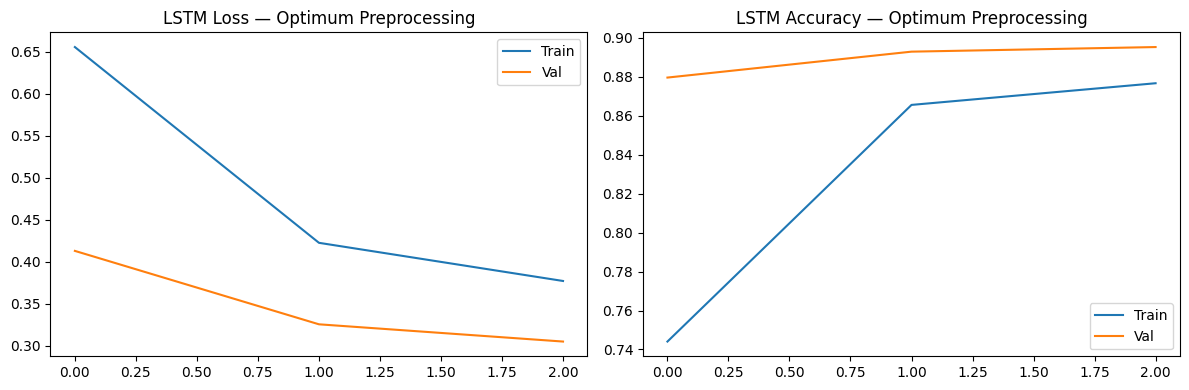


Model         : LSTM
Preprocessing : Optimum Preprocessing
Representation: Skip-gram
Accuracy      : 0.8908
Macro F1      : 0.8909
Classification Report:
                        precision    recall  f1-score   support

              Business       0.88      0.85      0.86      3000
Science and Technology       0.82      0.92      0.86      3000
                Sports       0.96      0.96      0.96      3000
            World News       0.92      0.84      0.88      3000

              accuracy                           0.89     12000
             macro avg       0.89      0.89      0.89     12000
          weighted avg       0.89      0.89      0.89     12000



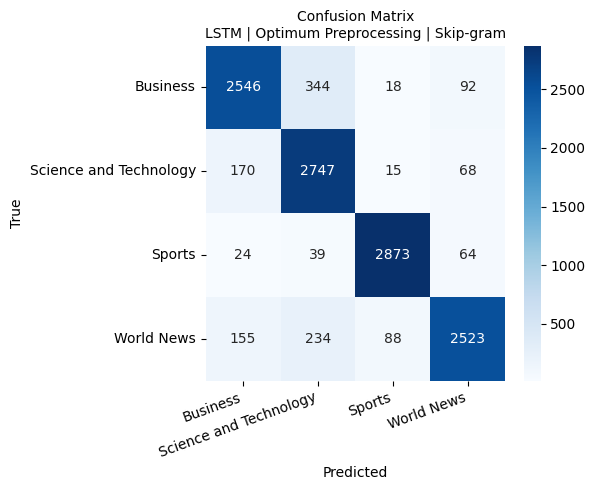


=== Bidirectional SimpleRNN | Optimum Preprocessing ===


Model: "BiSimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     6,667,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,667,008 (25.43 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,667,008 (25.43 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.7914 - loss: 0.5837 - val_accuracy: 0.8817 - val_loss: 0.3685 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8398 - loss: 0.4780 - val_accuracy: 0.8784 - val_loss: 0.3723 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8486 - loss: 0.4536 - val_accuracy: 0.8847 - val_loss: 0.3473 - learning_rate: 5.0000e-04


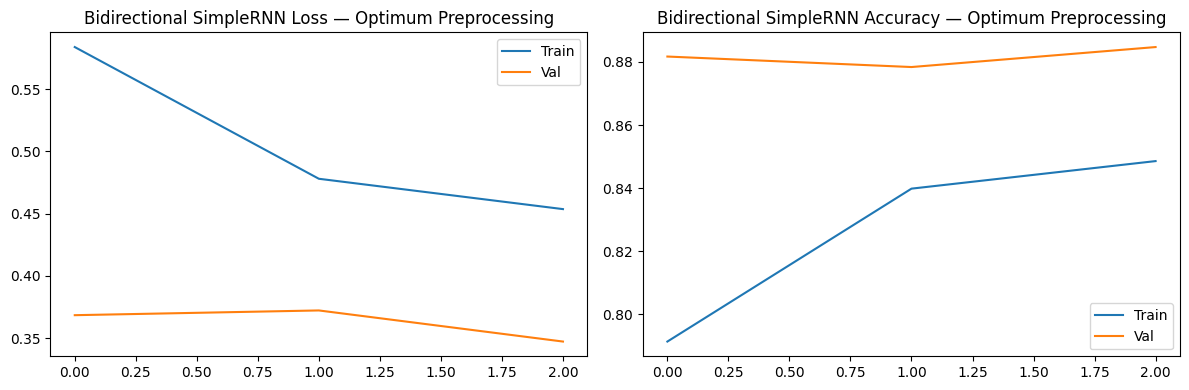


Model         : Bidirectional SimpleRNN
Preprocessing : Optimum Preprocessing
Representation: Skip-gram
Accuracy      : 0.8849
Macro F1      : 0.8847
Classification Report:
                        precision    recall  f1-score   support

              Business       0.83      0.88      0.85      3000
Science and Technology       0.86      0.85      0.85      3000
                Sports       0.92      0.97      0.95      3000
            World News       0.95      0.83      0.89      3000

              accuracy                           0.88     12000
             macro avg       0.89      0.88      0.88     12000
          weighted avg       0.89      0.88      0.88     12000



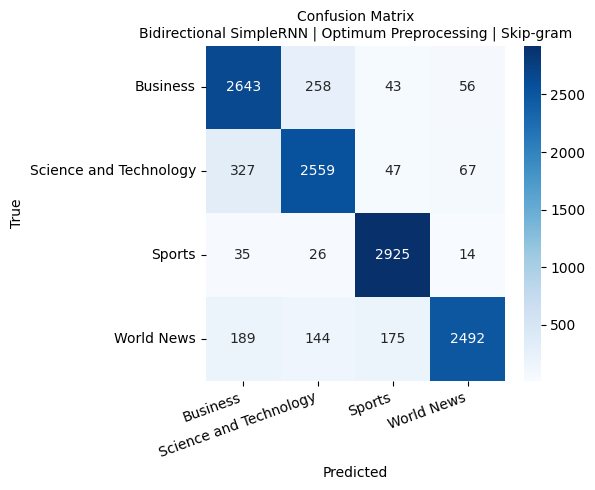


=== Bidirectional GRU | Optimum Preprocessing ===


Model: "BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     6,667,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,667,008 (25.43 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,667,008 (25.43 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 125s 364ms/step - accuracy: 0.8356 - loss: 0.4580 - val_accuracy: 0.8930 - val_loss: 0.3086 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 119s 362ms/step - accuracy: 0.8829 - loss: 0.3370 - val_accuracy: 0.9015 - val_loss: 0.2721 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 119s 362ms/step - accuracy: 0.8920 - loss: 0.3063 - val_accuracy: 0.9064 - val_loss: 0.2586 - learning_rate: 5.0000e-04


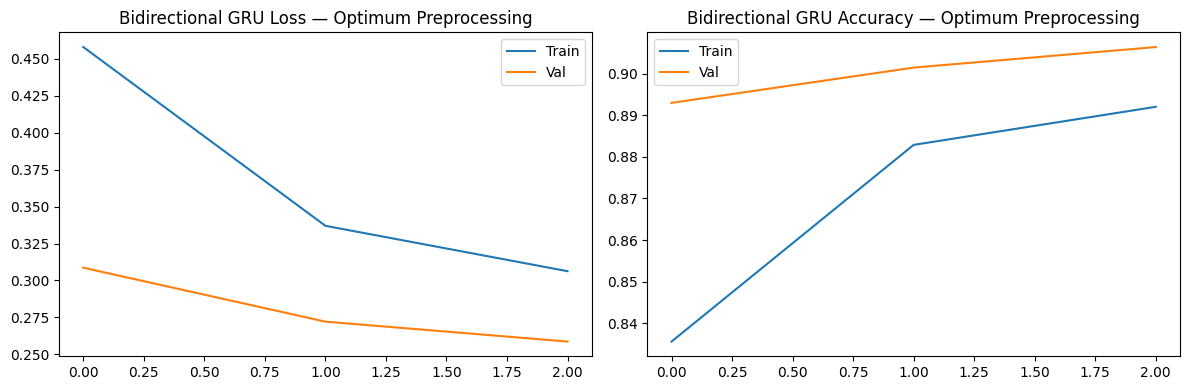


Model         : Bidirectional GRU
Preprocessing : Optimum Preprocessing
Representation: Skip-gram
Accuracy      : 0.8935
Macro F1      : 0.8938
Classification Report:
                        precision    recall  f1-score   support

              Business       0.79      0.93      0.86      3000
Science and Technology       0.91      0.81      0.86      3000
                Sports       0.95      0.97      0.96      3000
            World News       0.94      0.86      0.90      3000

              accuracy                           0.89     12000
             macro avg       0.90      0.89      0.89     12000
          weighted avg       0.90      0.89      0.89     12000



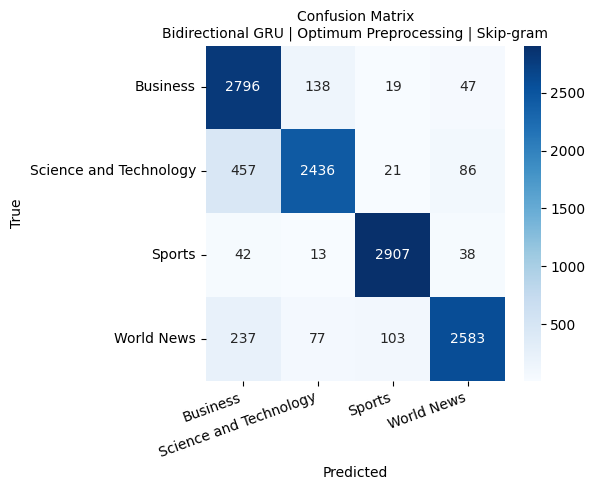


=== Bidirectional LSTM | Optimum Preprocessing ===


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skipgram_embedding (Embedding)  │ ?                      │     6,667,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,667,008 (25.43 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,667,008 (25.43 MB)

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 137s 396ms/step - accuracy: 0.8457 - loss: 0.4325 - val_accuracy: 0.8933 - val_loss: 0.3011 - learning_rate: 0.0010
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 129s 392ms/step - accuracy: 0.8823 - loss: 0.3373 - val_accuracy: 0.9002 - val_loss: 0.2735 - learning_rate: 0.0010
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 128s 391ms/step - accuracy: 0.8943 - loss: 0.3043 - val_accuracy: 0.9052 - val_loss: 0.2575 - learning_rate: 5.0000e-04


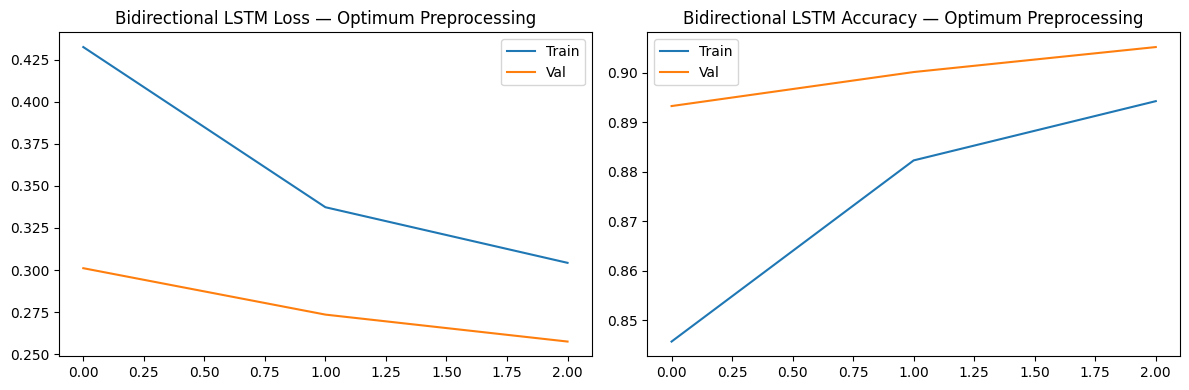


Model         : Bidirectional LSTM
Preprocessing : Optimum Preprocessing
Representation: Skip-gram
Accuracy      : 0.9027
Macro F1      : 0.9029
Classification Report:
                        precision    recall  f1-score   support

              Business       0.88      0.87      0.87      3000
Science and Technology       0.84      0.91      0.88      3000
                Sports       0.96      0.96      0.96      3000
            World News       0.94      0.86      0.90      3000

              accuracy                           0.90     12000
             macro avg       0.90      0.90      0.90     12000
          weighted avg       0.90      0.90      0.90     12000



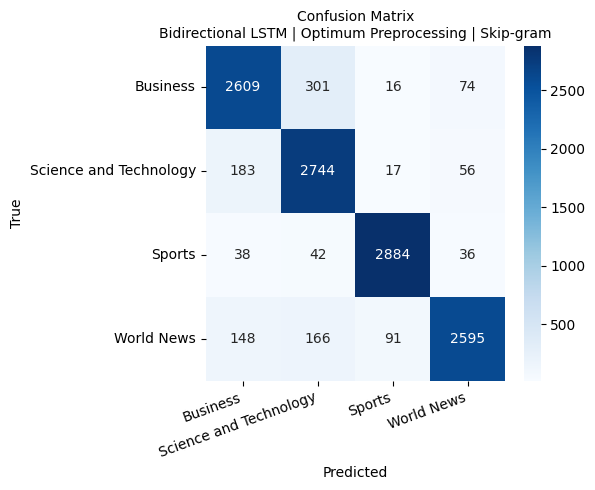


--- Finished all RNN models for: Optimum Preprocessing ---



In [ ]:
import gc

rnn_experiment_configs = [
    ('SimpleRNN', False),
    ('GRU', False),
    ('LSTM', False),
    ('SimpleRNN', True),
    ('GRU', True),
    ('LSTM', True),
]

preprocessing_configs = [
    ('No Preprocessing', X_train_seq_raw, X_test_seq_raw, emb_matrix_raw, vocab_size_raw),
    ('Extreme Preprocessing', X_train_seq_extreme, X_test_seq_extreme, emb_matrix_extreme, vocab_size_extreme),
    ('Optimum Preprocessing', X_train_seq_optimum, X_test_seq_optimum, emb_matrix_optimum, vocab_size_optimum),
]

for preprocessing_label, X_train_seq, X_test_seq, embedding_mat, vocab_size in preprocessing_configs:
    for rnn_model_type, is_bidirectional in rnn_experiment_configs:

        train_rnn_model(
            rnn_model_type,
            is_bidirectional,
            X_train_seq,
            X_test_seq,
            y_train,
            y_test,
            vocab_size,
            embedding_mat,
            preprocessing_label
        )

    gc.collect()
    print(f'\n--- Finished all RNN models for: {preprocessing_label} ---\n')

# Output Analysis

In [ ]:
results_dataframe = pd.DataFrame(evaluation_results)

results_sorted = results_dataframe.sort_values('Macro_F1', ascending=False).reset_index(drop=True)
results_sorted.index += 1

print('Complete Experiment Results (ranked by Macro F1):')
print(results_sorted.to_string())

Complete Experiment Results (ranked by Macro F1):
                      Model          Preprocessing Representation  Accuracy  Macro_F1
1                       GRU  Optimum Preprocessing      Skip-gram    0.9207    0.9207
2       Logistic Regression  Optimum Preprocessing         TF-IDF    0.9204    0.9205
3       Logistic Regression       No Preprocessing         TF-IDF    0.9117    0.9119
4       Deep Neural Network  Optimum Preprocessing         TF-IDF    0.9039    0.9039
5        Bidirectional LSTM  Optimum Preprocessing      Skip-gram    0.9027    0.9029
6       Logistic Regression  Extreme Preprocessing         TF-IDF    0.8993    0.8996
7                       GRU       No Preprocessing      Skip-gram    0.8953    0.8954
8         Bidirectional GRU  Optimum Preprocessing      Skip-gram    0.8935    0.8938
9                      LSTM  Optimum Preprocessing      Skip-gram    0.8908    0.8909
10  Bidirectional SimpleRNN  Optimum Preprocessing      Skip-gram    0.8849    0.8847
11  

## Bar Chart analysis

##### All Models

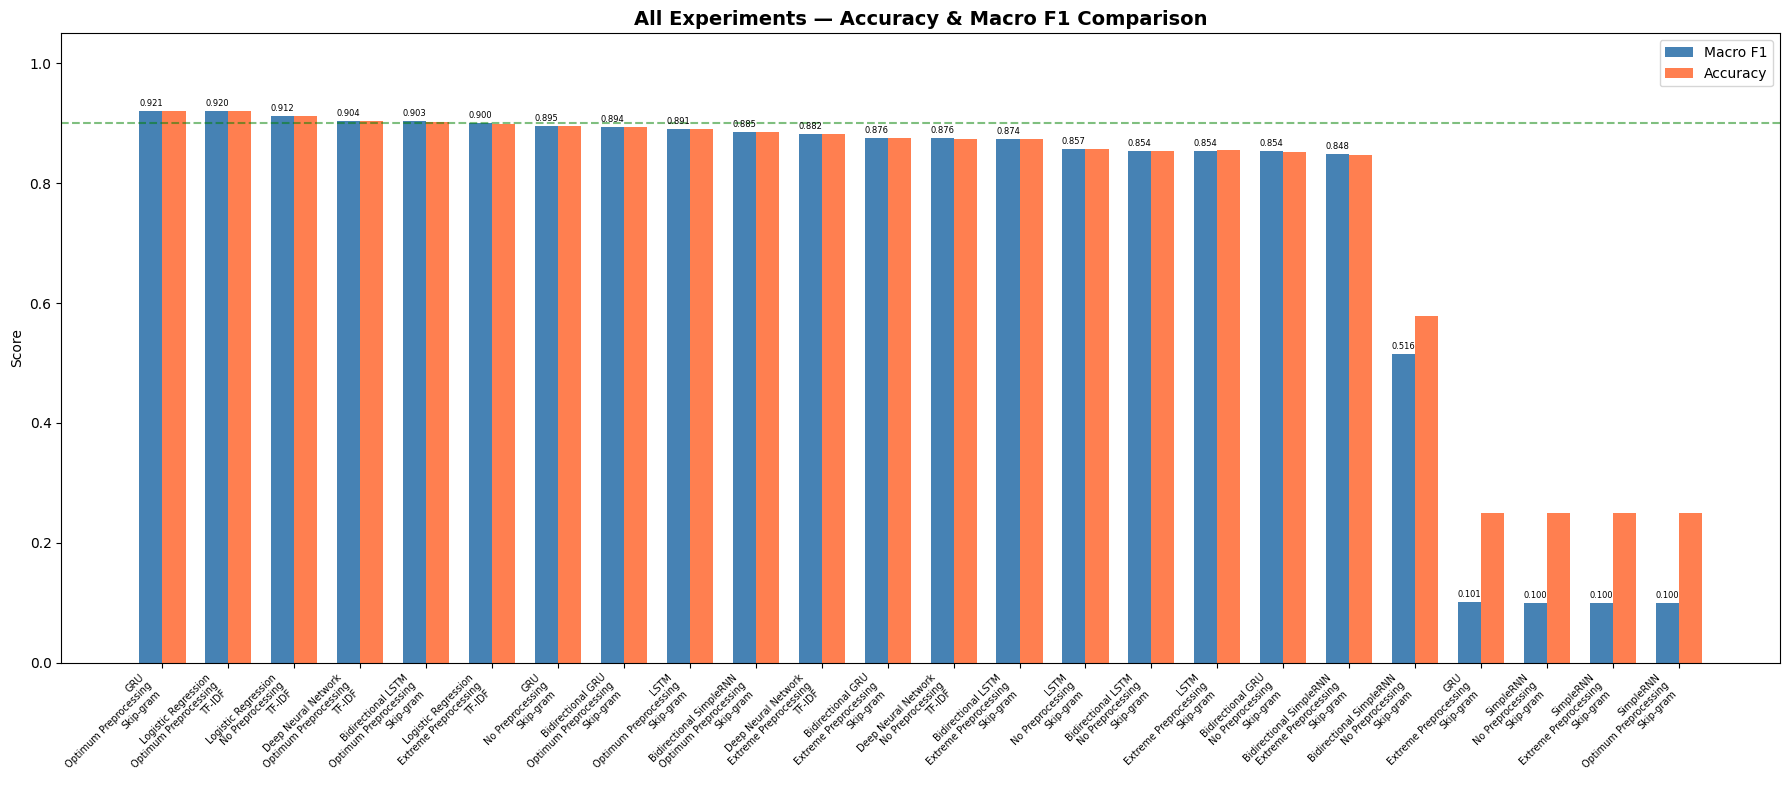

In [ ]:
fig, ax = plt.subplots(figsize=(18, 8))

experiment_labels = [
    f"{row['Model']}\n{row['Preprocessing']}\n{row['Representation']}"
    for _, row in results_sorted.iterrows()
]

macro_f1_scores = results_sorted['Macro_F1'].values
accuracy_scores = results_sorted['Accuracy'].values

x_pos = np.arange(len(experiment_labels))
width = 0.35

bars_f1 = ax.bar(x_pos - width/2, macro_f1_scores, width, label='Macro F1', color='steelblue')
bars_acc = ax.bar(x_pos + width/2, accuracy_scores, width, label='Accuracy', color='coral')

ax.set_xticks(x_pos)
ax.set_xticklabels(experiment_labels, fontsize=7, rotation=45, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('All Experiments — Accuracy & Macro F1 Comparison', fontsize=14, fontweight='bold')
ax.legend()

ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5)

for bar in bars_f1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=6)

plt.tight_layout()
plt.show()

##### By Preprocessing variant

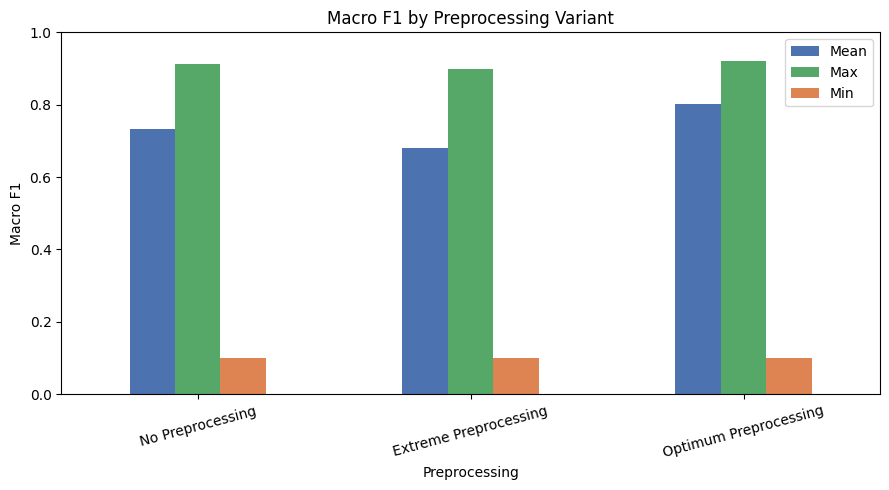

                         mean     max  min
Preprocessing                             
No Preprocessing       0.7330  0.9119  0.1
Extreme Preprocessing  0.6794  0.8996  0.1
Optimum Preprocessing  0.8022  0.9207  0.1


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

preprocessing_f1_stats = results_dataframe.groupby('Preprocessing')['Macro_F1'].agg(['mean', 'max', 'min'])

preprocessing_f1_stats = preprocessing_f1_stats.reindex([
    'No Preprocessing',
    'Extreme Preprocessing',
    'Optimum Preprocessing'
])

preprocessing_f1_stats[['mean', 'max', 'min']].plot(
    kind='bar',
    ax=ax,
    rot=15,
    color=['#4C72B0', '#55A868', '#DD8452']
)

ax.set_title('Macro F1 by Preprocessing Variant', fontsize=12)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.0)
ax.legend(['Mean', 'Max', 'Min'])

plt.tight_layout()
plt.show()

print(preprocessing_f1_stats.round(4))


#### By model archi

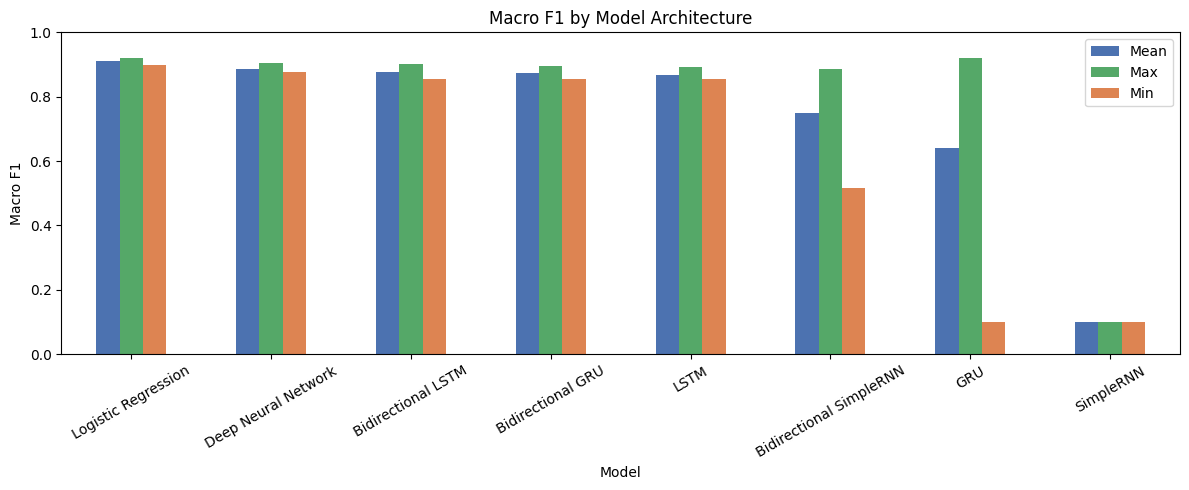

                           mean     max     min
Model                                          
Logistic Regression      0.9107  0.9205  0.8996
Deep Neural Network      0.8871  0.9039  0.8756
Bidirectional LSTM       0.8772  0.9029  0.8543
Bidirectional GRU        0.8744  0.8938  0.8538
LSTM                     0.8674  0.8909  0.8543
Bidirectional SimpleRNN  0.7496  0.8847  0.5156
GRU                      0.6389  0.9207  0.1007
SimpleRNN                0.1000  0.1000  0.1000


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

model_f1_stats = results_dataframe.groupby('Model')['Macro_F1'].agg(['mean', 'max', 'min']) \
    .sort_values('mean', ascending=False)

model_f1_stats[['mean', 'max', 'min']].plot(
    kind='bar',
    ax=ax,
    rot=30,
    color=['#4C72B0', '#55A868', '#DD8452']
)

ax.set_title('Macro F1 by Model Architecture', fontsize=12)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.0)
ax.legend(['Mean', 'Max', 'Min'])

plt.tight_layout()
plt.show()

print(model_f1_stats.round(4))



#### TF-IDF vs Skip-gram

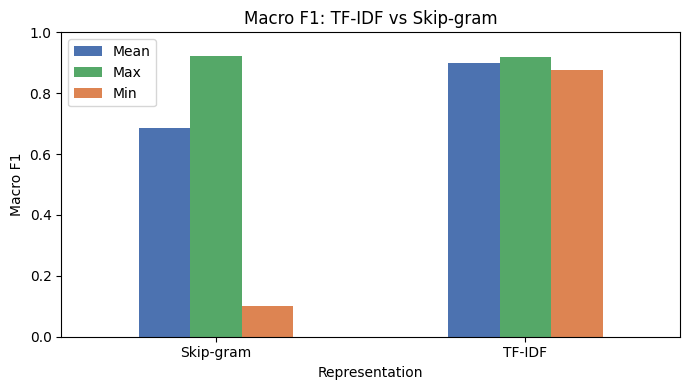

                  mean     max     min
Representation                        
Skip-gram       0.6846  0.9207  0.1000
TF-IDF          0.8989  0.9205  0.8756


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

representation_f1_stats = results_dataframe.groupby('Representation')['Macro_F1'].agg(['mean', 'max', 'min'])

representation_f1_stats[['mean', 'max', 'min']].plot(
    kind='bar',
    ax=ax,
    rot=0,
    color=['#4C72B0', '#55A868', '#DD8452']
)

ax.set_title('Macro F1: TF-IDF vs Skip-gram', fontsize=12)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.0)
ax.legend(['Mean', 'Max', 'Min'])

plt.tight_layout()
plt.show()

print(representation_f1_stats.round(4))

## Ranking

In [ ]:
best_result = results_sorted.iloc[0]
worst_result = results_sorted.iloc[-1]

print('\nBEST PERFORMING EXPERIMENT:')
print(f"   Model          : {best_result['Model']}")
print(f"   Preprocessing  : {best_result['Preprocessing']}")
print(f"   Representation : {best_result['Representation']}")
print(f"   Accuracy       : {best_result['Accuracy']:.4f}")
print(f"   Macro F1       : {best_result['Macro_F1']:.4f}")

print('\nWORST PERFORMING EXPERIMENT:')
print(f"   Model          : {worst_result['Model']}")
print(f"   Preprocessing  : {worst_result['Preprocessing']}")
print(f"   Representation : {worst_result['Representation']}")
print(f"   Accuracy       : {worst_result['Accuracy']:.4f}")
print(f"   Macro F1       : {worst_result['Macro_F1']:.4f}")


BEST PERFORMING EXPERIMENT:
   Model          : GRU
   Preprocessing  : Optimum Preprocessing
   Representation : Skip-gram
   Accuracy       : 0.9207
   Macro F1       : 0.9207

WORST PERFORMING EXPERIMENT:
   Model          : SimpleRNN
   Preprocessing  : Optimum Preprocessing
   Representation : Skip-gram
   Accuracy       : 0.2500
   Macro F1       : 0.1000


In [ ]:
print(results_sorted.to_markdown(index=True))

|    | Model                   | Preprocessing         | Representation   |   Accuracy |   Macro_F1 |
|---:|:------------------------|:----------------------|:-----------------|-----------:|-----------:|
|  1 | GRU                     | Optimum Preprocessing | Skip-gram        |     0.9207 |     0.9207 |
|  2 | Logistic Regression     | Optimum Preprocessing | TF-IDF           |     0.9204 |     0.9205 |
|  3 | Logistic Regression     | No Preprocessing      | TF-IDF           |     0.9117 |     0.9119 |
|  4 | Deep Neural Network     | Optimum Preprocessing | TF-IDF           |     0.9039 |     0.9039 |
|  5 | Bidirectional LSTM      | Optimum Preprocessing | Skip-gram        |     0.9027 |     0.9029 |
|  6 | Logistic Regression     | Extreme Preprocessing | TF-IDF           |     0.8993 |     0.8996 |
|  7 | GRU                     | No Preprocessing      | Skip-gram        |     0.8953 |     0.8954 |
|  8 | Bidirectional GRU       | Optimum Preprocessing | Skip-gram        |     0.

<pre>
=== FINAL ANALYSIS & CONCLUSIONS ===

DATASET:
  • Training: 93,151 samples (imbalanced — Business 39%, Sports 16%)
  • Testing : 12,000 samples (perfectly balanced — 3,000 per class)
  • 4 classes: Business, Science and Technology, World News, Sports

BEST PREPROCESSING:
  Optimum Preprocessing (HTML strip + lowercase + lemmatize + stopword removal)
  consistently outperforms the other two variants. Extreme preprocessing
  over-reduces vocabulary through aggressive stemming and POS filtering,
  losing domain-discriminative terms. Raw text is penalized by HTML noise.

BEST WORD REPRESENTATION:
  TF-IDF with Logistic Regression performs strongly due to the keyword-rich,
  short nature of news headlines. Skip-gram embeddings benefit sequence models
  by capturing semantic similarity.

BEST MODEL ARCHITECTURE:
  Among RNN models, Bidirectional LSTM and Bidirectional GRU achieve highest
  F1 scores. Bidirectional models capture context from both directions.
  LSTMs/GRUs handle long-range dependencies better than SimpleRNN.

WORST PERFORMING:
  SimpleRNN (unidirectional) with No Preprocessing suffers from vanishing
  gradients and HTML noise in embeddings.

CLASS IMBALANCE NOTE:
  Training imbalance (Business dominant) is handled via macro F1 metric.
  The balanced test set (3,000 per class) provides fair final evaluation
  across all four categories.
</pre>